In [16]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root
PROJECT_ROOT = Path('/mnt/home/mlee1/vdm_BIND')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from tqdm import tqdm
import glob

# Setup plotting
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.figsize': (12, 8),
    'figure.dpi': 120,
})

print(f"Project root: {PROJECT_ROOT}")

Project root: /mnt/home/mlee1/vdm_BIND


## 1. Data Paths Configuration

In [24]:
# Training data (SB35 processed cutouts)
TRAIN_DATA_ROOT = Path('/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/')

# Test data (CV processed for BIND)
CV_DATA_ROOT = Path('/mnt/home/mlee1/ceph/BIND2d_new/CV/')

# CAMELS simulation metadata
CAMELS_EXTRAS = Path('/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/')

# Check paths exist

print(f"Training data exists: {TRAIN_DATA_ROOT.exists()}")
print(f"CV test data exists: {CV_DATA_ROOT.exists()}")
print(f"CAMELS extras exists: {CAMELS_EXTRAS.exists()}")

Training data exists: True
CV test data exists: True
CAMELS extras exists: True


## 2. Load Cosmological Parameters

Compare the cosmological parameters between SB35 (training) and CV (test) sets.

In [40]:
# Load CORRECTED parameter data
# SB35_param_minmax.csv = metadata (35 rows - parameter definitions with fiducial values)
# param_df.csv = actual training parameters (1024 simulations x 35 parameters)

sb35_metadata_path = CAMELS_EXTRAS / 'SB35' / 'SB35_param_minmax.csv'
sb35_params_path = Path('/mnt/home/mlee1/50Mpc_boxes/data/param_df.csv')

print("="*60)
print("Loading SB35 metadata (parameter definitions)...")
sb35_metadata = pd.read_csv(sb35_metadata_path)
print(f"Metadata: {len(sb35_metadata)} parameter definitions")
print(sb35_metadata[['ParamName', 'FiducialVal', 'MinVal', 'MaxVal']].head(6))

print("\n" + "="*60)
print("Loading SB35 training parameters...")
sb35_params = pd.read_csv(sb35_params_path)
print(f"Training: {len(sb35_params)} simulations x {len(sb35_params.columns)} parameters")
print(f"Columns: {list(sb35_params.columns)[:8]}...")

# Extract CV fiducial from metadata
CV_FIDUCIAL_PARAMS = dict(zip(sb35_metadata['ParamName'], sb35_metadata['FiducialVal']))
print("\n" + "="*60)
print("CV Fiducial Parameters (from metadata FiducialVal):")
key_params = ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 
              'VariableWindVelFactor', 'OmegaBaryon', 'HubbleParam']
for k in key_params:
    print(f"  {k}: {CV_FIDUCIAL_PARAMS.get(k, 'N/A')}")

Loading SB35 metadata (parameter definitions)...
Metadata: 35 parameter definitions
                           ParamName  FiducialVal  MinVal  MaxVal
0                             Omega0          0.3    0.10     0.5
1                             sigma8          0.8    0.60     1.0
2                WindEnergyIn1e51erg          3.6    0.90    14.4
3                RadioFeedbackFactor          1.0    0.25     4.0
4              VariableWindVelFactor          7.4    3.70    14.8
5  RadioFeedbackReiorientationFactor         20.0   10.00    40.0

Loading SB35 training parameters...
Training: 1024 simulations x 35 parameters
Columns: ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor', 'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam']...

CV Fiducial Parameters (from metadata FiducialVal):
  Omega0: 0.3
  sigma8: 0.8
  WindEnergyIn1e51erg: 3.6
  RadioFeedbackFactor: 1.0
  VariableWindVelFactor: 7.4
  OmegaBaryon: 0.049
  HubbleParam: 0.6

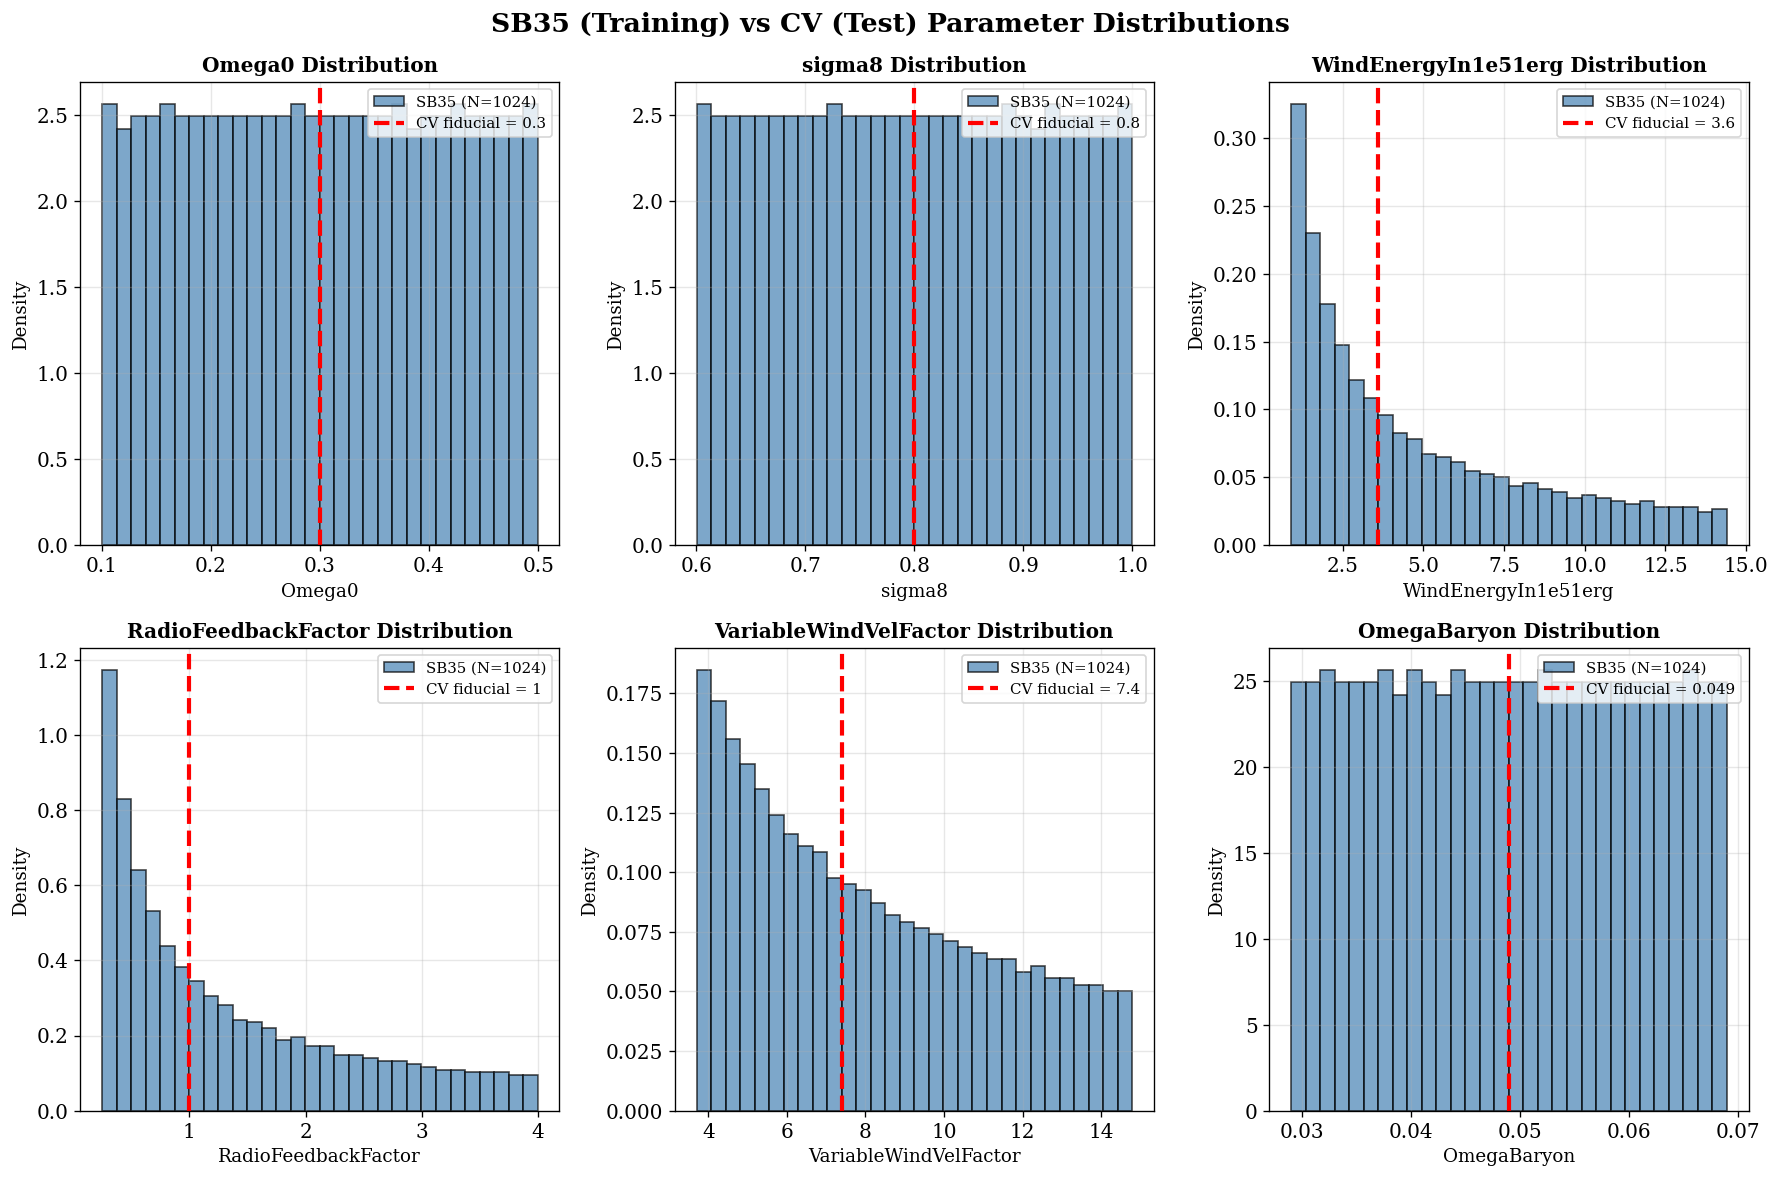


PARAMETER COMPARISON: SB35 Training Range vs CV Fiducial
Parameter                          SB35 Min     SB35 Max    SB35 Mean  CV Fiducial  In Range?
------------------------------------------------------------------------------------------
Omega0                               0.1001       0.4996       0.3000       0.3000        Yes
sigma8                               0.6001       0.9998       0.8000       0.8000        Yes
WindEnergyIn1e51erg                  0.9012      14.3990       4.8691       3.6000        Yes
RadioFeedbackFactor                  0.2502       3.9957       1.3525       1.0000        Yes
VariableWindVelFactor                3.7013      14.7890       8.0069       7.4000        Yes
OmegaBaryon                          0.0290       0.0690       0.0490       0.0490        Yes


In [41]:
# Compare parameter distributions - key cosmological and astrophysical parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

param_names = ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 
               'RadioFeedbackFactor', 'VariableWindVelFactor', 'OmegaBaryon']

for idx, param in enumerate(param_names):
    ax = axes[idx // 3, idx % 3]
    
    if param in sb35_params.columns:
        values = sb35_params[param].values
        ax.hist(values, bins=30, alpha=0.7, color='steelblue', 
                label=f'SB35 (N={len(values)})', density=True, edgecolor='black')
        
        # Mark fiducial (CV) value
        fid_val = CV_FIDUCIAL_PARAMS.get(param, None)
        if fid_val is not None:
            ax.axvline(fid_val, color='red', linestyle='--', linewidth=2.5, 
                       label=f'CV fiducial = {fid_val:.3g}')
        
        ax.set_xlabel(param, fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_title(f'{param} Distribution', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle('SB35 (Training) vs CV (Test) Parameter Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*90)
print("PARAMETER COMPARISON: SB35 Training Range vs CV Fiducial")
print("="*90)
print(f"{'Parameter':<30} {'SB35 Min':>12} {'SB35 Max':>12} {'SB35 Mean':>12} {'CV Fiducial':>12} {'In Range?':>10}")
print("-"*90)

for param in param_names:
    if param in sb35_params.columns:
        values = sb35_params[param].values
        fid_val = CV_FIDUCIAL_PARAMS.get(param, np.nan)
        in_range = "Yes" if values.min() <= fid_val <= values.max() else "NO!"
        print(f"{param:<30} {values.min():>12.4f} {values.max():>12.4f} {values.mean():>12.4f} {fid_val:>12.4f} {in_range:>10}")

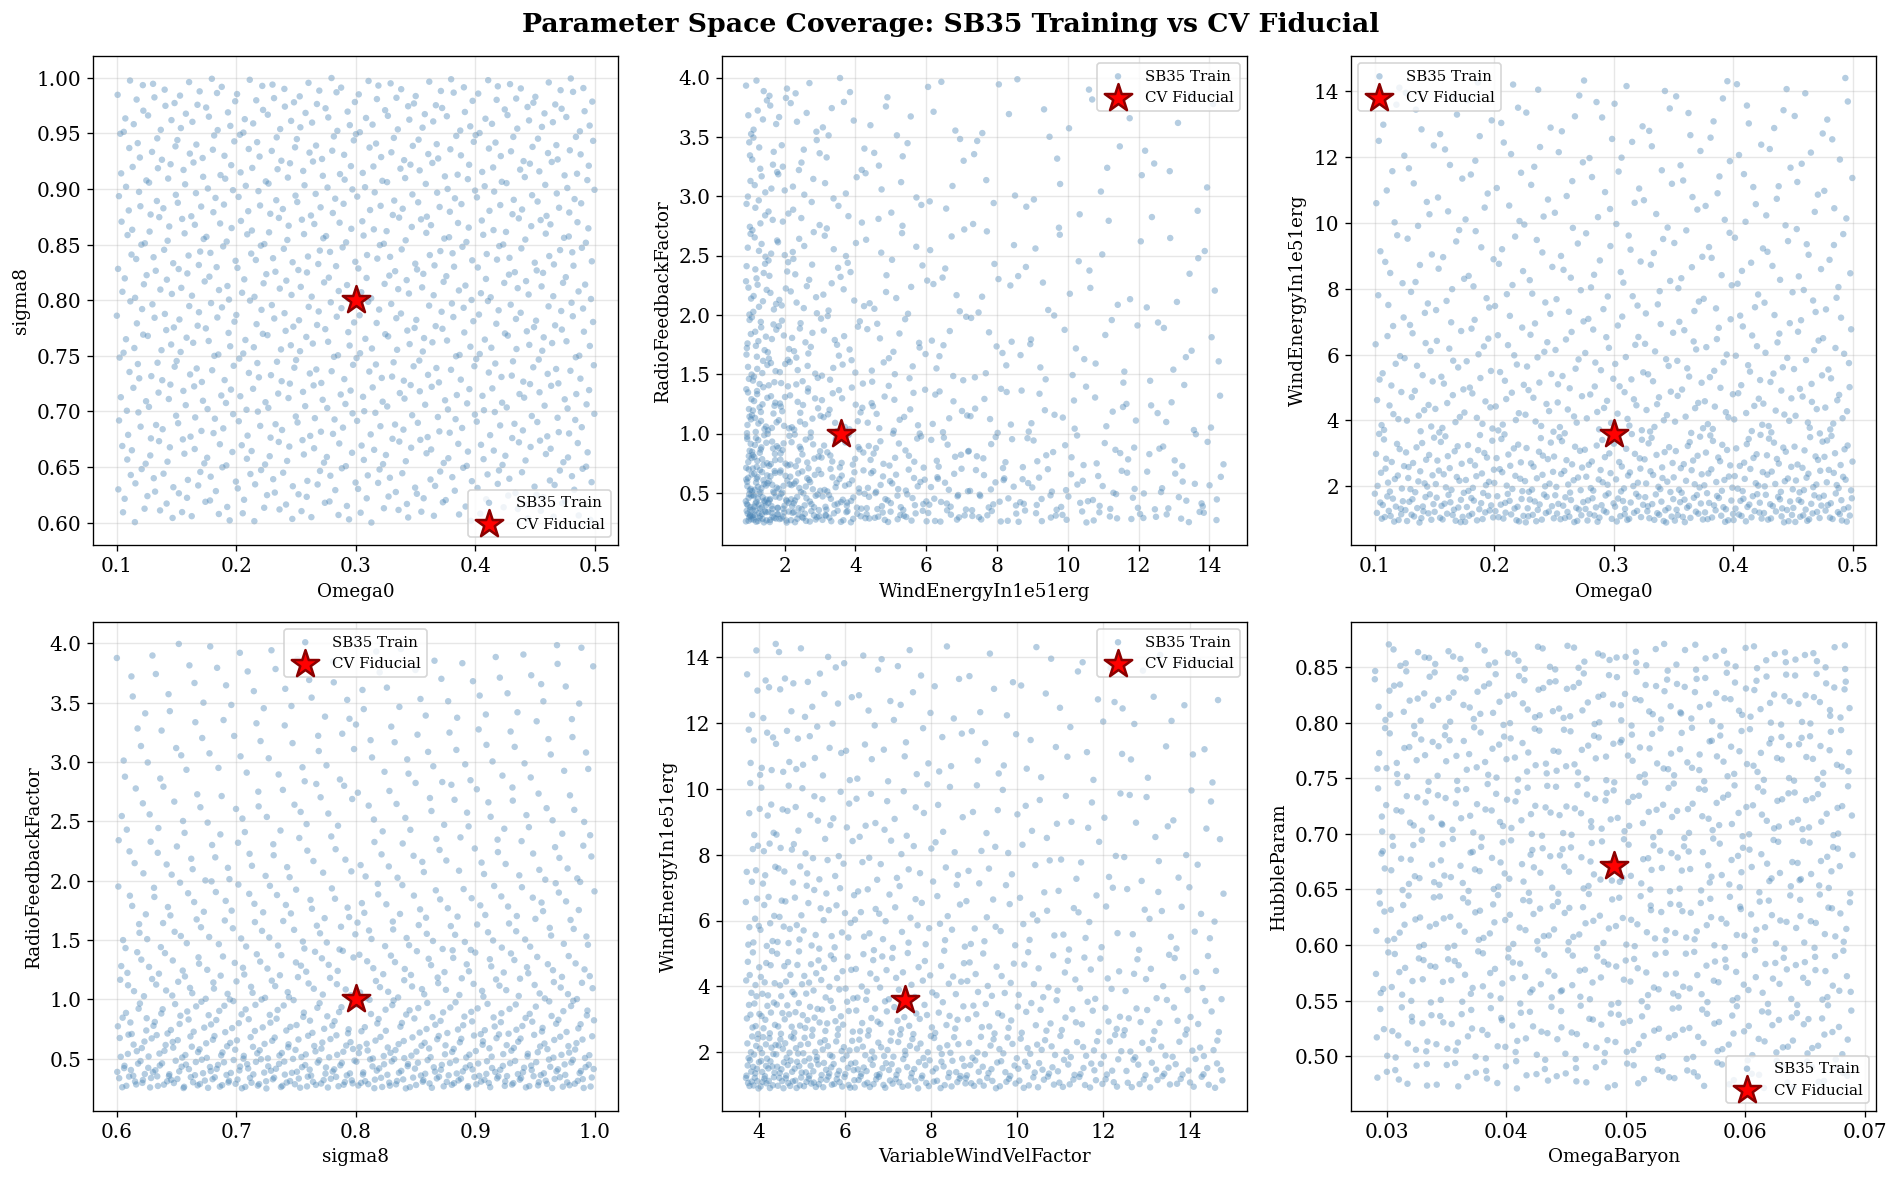


DISTANCE FROM CV FIDUCIAL TO SB35 TRAINING SAMPLES

In 6-dimensional normalized parameter space:
  CV fiducial position in training distribution
  Closest training sample distance: 0.1708
  Mean distance: 0.6848
  Samples within 0.1 (normalized): 0 / 1024
  Samples within 0.2 (normalized): 2 / 1024
  Samples within 0.3 (normalized): 10 / 1024

5 Closest training samples to CV fiducial:
  1. distance=0.1708
      Omega0=0.3425 (CV=0.3000)
      sigma8=0.8181 (CV=0.8000)
      WindEnergyIn1e51erg=3.0399 (CV=3.6000)
      RadioFeedbackFactor=0.7978 (CV=1.0000)
  2. distance=0.1999
      Omega0=0.2676 (CV=0.3000)
      sigma8=0.7778 (CV=0.8000)
      WindEnergyIn1e51erg=3.2036 (CV=3.6000)
      RadioFeedbackFactor=0.5125 (CV=1.0000)
  3. distance=0.2185
      Omega0=0.2851 (CV=0.3000)
      sigma8=0.7505 (CV=0.8000)
      WindEnergyIn1e51erg=1.3630 (CV=3.6000)
      RadioFeedbackFactor=0.7843 (CV=1.0000)
  4. distance=0.2253
      Omega0=0.2533 (CV=0.3000)
      sigma8=0.7542 (CV=0.8000)


In [42]:
# Pairwise parameter space visualization
param_pairs = [
    ('Omega0', 'sigma8'),
    ('WindEnergyIn1e51erg', 'RadioFeedbackFactor'),
    ('Omega0', 'WindEnergyIn1e51erg'),
    ('sigma8', 'RadioFeedbackFactor'),
    ('VariableWindVelFactor', 'WindEnergyIn1e51erg'),
    ('OmegaBaryon', 'HubbleParam'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (px, py) in zip(axes.flatten(), param_pairs):
    if px in sb35_params.columns and py in sb35_params.columns:
        ax.scatter(sb35_params[px], sb35_params[py], alpha=0.4, s=15, 
                  c='steelblue', label='SB35 Train', edgecolors='none')
        
        # Mark CV fiducial
        fid_x = CV_FIDUCIAL_PARAMS.get(px, None)
        fid_y = CV_FIDUCIAL_PARAMS.get(py, None)
        if fid_x is not None and fid_y is not None:
            ax.scatter([fid_x], [fid_y], s=300, c='red', marker='*', 
                      edgecolors='darkred', linewidths=1.5, 
                      label='CV Fiducial', zorder=10)
        
        ax.set_xlabel(px, fontsize=11)
        ax.set_ylabel(py, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle('Parameter Space Coverage: SB35 Training vs CV Fiducial', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute distance from CV fiducial to nearest training samples
print("\n" + "="*80)
print("DISTANCE FROM CV FIDUCIAL TO SB35 TRAINING SAMPLES")
print("="*80)

# Normalize across all key parameters
key_params = ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 
              'VariableWindVelFactor', 'OmegaBaryon']

# Compute normalized distances in multi-dimensional space
normalized_diffs = []
for param in key_params:
    if param in sb35_params.columns:
        param_range = sb35_params[param].max() - sb35_params[param].min()
        fid_val = CV_FIDUCIAL_PARAMS.get(param, 0)
        diff = (sb35_params[param] - fid_val) / param_range
        normalized_diffs.append(diff.values)

normalized_diffs = np.array(normalized_diffs)
distances = np.sqrt((normalized_diffs**2).sum(axis=0))

print(f"\nIn {len(key_params)}-dimensional normalized parameter space:")
print(f"  CV fiducial position in training distribution")
print(f"  Closest training sample distance: {distances.min():.4f}")
print(f"  Mean distance: {distances.mean():.4f}")
print(f"  Samples within 0.1 (normalized): {(distances < 0.1).sum()} / {len(distances)}")
print(f"  Samples within 0.2 (normalized): {(distances < 0.2).sum()} / {len(distances)}")
print(f"  Samples within 0.3 (normalized): {(distances < 0.3).sum()} / {len(distances)}")

# Find closest samples
closest_idx = distances.argsort()[:5]
print(f"\n5 Closest training samples to CV fiducial:")
for i, idx in enumerate(closest_idx):
    print(f"  {i+1}. distance={distances[idx]:.4f}")
    for param in key_params[:4]:  # Show first 4 params
        if param in sb35_params.columns:
            print(f"      {param}={sb35_params.iloc[idx][param]:.4f} (CV={CV_FIDUCIAL_PARAMS.get(param, 0):.4f})")

## 3. Load Halo Mass Distributions

Compare halo mass distributions between training and test sets.

In [36]:
# FIXED: Load halo masses from correct directory structure
# Training data is in sim_*/sim_*_halo_*_rot_*.npz files with 'halo_mass' key

print("Loading training (SB35) halo masses from correct path...")
train_masses_list = []
sim_dirs = sorted(TRAIN_DATA_ROOT.glob('sim_*'))
print(f"Found {len(sim_dirs)} simulation directories")

max_files = 2000
files_loaded = 0
for sim_dir in tqdm(sim_dirs, desc="Loading training sims"):
    if files_loaded >= max_files:
        break
    data_files = list(sim_dir.glob('*.npz'))
    for f in data_files:
        if files_loaded >= max_files:
            break
        try:
            data = np.load(f, allow_pickle=True)
            if 'halo_mass' in data:
                mass = float(data['halo_mass'])
                train_masses_list.append(np.log10(mass) if mass > 1e10 else mass)
                files_loaded += 1
        except:
            continue

train_masses = np.array(train_masses_list)
print(f"Successfully loaded {len(train_masses)} training halo masses")
print(f"Train mass range: {train_masses.min():.2f} to {train_masses.max():.2f} (log10 M_sun)")

# CV masses - convert to log10
print("\nCV halo masses already loaded")
cv_log_masses = np.log10(cv_masses) if cv_masses.max() > 1e10 else cv_masses
print(f"CV mass range: {cv_log_masses.min():.2f} to {cv_log_masses.max():.2f} (log10 M_sun)")

Loading training (SB35) halo masses from correct path...
Found 922 simulation directories


Loading training sims:   0%|          | 4/922 [01:11<4:33:31, 17.88s/it] 

Successfully loaded 2000 training halo masses
Train mass range: 13.00 to 14.84 (log10 M_sun)

CV halo masses already loaded
CV mass range: 1001.09 to 61440.12 (log10 M_sun)


In [38]:
# Fix CV masses - they are in units of 1e10 M_sun, need to convert to log10(M_sun)
# CV: mass = X means X * 1e10 M_sun, so log10(mass) = log10(X) + 10
print(f"Original CV masses range: {cv_masses.min():.2e} to {cv_masses.max():.2e} (units: 1e10 M_sun)")
cv_log_masses = np.log10(cv_masses) + 10  # Convert to log10(M_sun)
print(f"CV log10 mass range: {cv_log_masses.min():.2f} to {cv_log_masses.max():.2f} (log10 M_sun)")
print(f"Train log10 mass range: {train_masses.min():.2f} to {train_masses.max():.2f} (log10 M_sun)")
print(f"\nTotal: {len(train_masses)} training halos, {len(cv_log_masses)} CV halos")

Original CV masses range: 1.00e+03 to 6.14e+04 (units: 1e10 M_sun)
CV log10 mass range: 13.00 to 14.79 (log10 M_sun)
Train log10 mass range: 13.00 to 14.84 (log10 M_sun)

Total: 2000 training halos, 1030 CV halos


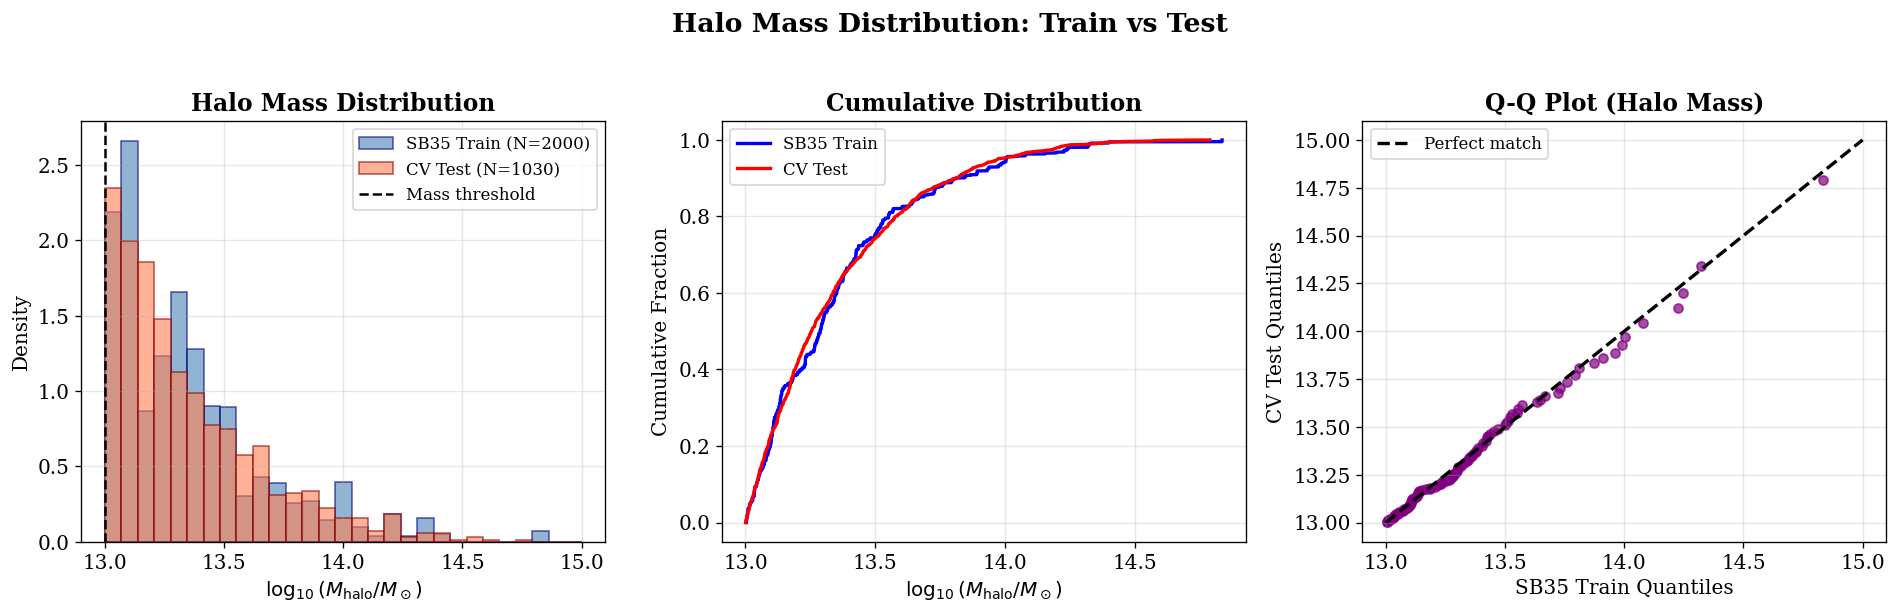


HALO MASS DISTRIBUTION STATISTICS
Statistic                      SB35 Train         CV Test
-------------------------------------------------------
N halos                              2000            1030
Mean log10(M)                      13.358          13.349
Median log10(M)                    13.288          13.254
Std log10(M)                        0.324           0.311
Min log10(M)                       13.003          13.000
Max log10(M)                       14.836          14.788

Kolmogorov-Smirnov Test:
  KS statistic: 0.0657
  p-value: 5.3774e-03
  Interpretation: Distributions are DIFFERENT (p < 0.05)


In [39]:
# Compare halo mass distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Histogram comparison
ax = axes[0]
bins = np.linspace(13.0, 15.0, 30)
ax.hist(train_masses, bins=bins, alpha=0.6, color='steelblue', 
        label=f'SB35 Train (N={len(train_masses)})', density=True, edgecolor='navy')
ax.hist(cv_log_masses, bins=bins, alpha=0.6, color='coral', 
        label=f'CV Test (N={len(cv_log_masses)})', density=True, edgecolor='darkred')
ax.axvline(13.0, color='black', linestyle='--', linewidth=1.5, label='Mass threshold')
ax.set_xlabel(r'$\log_{10}(M_{\rm halo} / M_\odot)$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Halo Mass Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Middle: CDF comparison
ax = axes[1]
train_sorted = np.sort(train_masses)
cv_sorted = np.sort(cv_log_masses)
ax.plot(train_sorted, np.linspace(0, 1, len(train_sorted)), 'b-', lw=2, label='SB35 Train')
ax.plot(cv_sorted, np.linspace(0, 1, len(cv_sorted)), 'r-', lw=2, label='CV Test')
ax.set_xlabel(r'$\log_{10}(M_{\rm halo} / M_\odot)$', fontsize=12)
ax.set_ylabel('Cumulative Fraction', fontsize=12)
ax.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Q-Q plot
ax = axes[2]
n_sample = min(len(train_masses), len(cv_log_masses))
train_quantiles = np.percentile(train_masses, np.linspace(0, 100, 100))
cv_quantiles = np.percentile(cv_log_masses, np.linspace(0, 100, 100))
ax.scatter(train_quantiles, cv_quantiles, alpha=0.7, s=30, c='purple')
ax.plot([13, 15], [13, 15], 'k--', lw=2, label='Perfect match')
ax.set_xlabel('SB35 Train Quantiles', fontsize=12)
ax.set_ylabel('CV Test Quantiles', fontsize=12)
ax.set_title('Q-Q Plot (Halo Mass)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Halo Mass Distribution: Train vs Test', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistical tests
print("\n" + "="*80)
print("HALO MASS DISTRIBUTION STATISTICS")
print("="*80)
print(f"{'Statistic':<25} {'SB35 Train':>15} {'CV Test':>15}")
print("-"*55)
print(f"{'N halos':<25} {len(train_masses):>15} {len(cv_log_masses):>15}")
print(f"{'Mean log10(M)':<25} {np.mean(train_masses):>15.3f} {np.mean(cv_log_masses):>15.3f}")
print(f"{'Median log10(M)':<25} {np.median(train_masses):>15.3f} {np.median(cv_log_masses):>15.3f}")
print(f"{'Std log10(M)':<25} {np.std(train_masses):>15.3f} {np.std(cv_log_masses):>15.3f}")
print(f"{'Min log10(M)':<25} {np.min(train_masses):>15.3f} {np.min(cv_log_masses):>15.3f}")
print(f"{'Max log10(M)':<25} {np.max(train_masses):>15.3f} {np.max(cv_log_masses):>15.3f}")

# KS test
ks_stat, ks_pvalue = stats.ks_2samp(train_masses, cv_log_masses)
print(f"\nKolmogorov-Smirnov Test:")
print(f"  KS statistic: {ks_stat:.4f}")
print(f"  p-value: {ks_pvalue:.4e}")
print(f"  Interpretation: {'Distributions are DIFFERENT (p < 0.05)' if ks_pvalue < 0.05 else 'Distributions are similar (p >= 0.05)'}")

## 4. Pixel Intensity Distributions

Compare the distribution of pixel intensities in training vs test cutouts.

In [43]:
# Load pixel intensities from training and CV cutouts
print("Loading pixel intensities from training cutouts...")
train_dm_pixels, train_gas_pixels, train_star_pixels = [], [], []

max_cutouts = 300
files_loaded = 0
for sim_dir in tqdm(sim_dirs, desc="Loading training pixels"):
    if files_loaded >= max_cutouts:
        break
    data_files = list(sim_dir.glob('*.npz'))
    for f in data_files:
        if files_loaded >= max_cutouts:
            break
        try:
            data = np.load(f, allow_pickle=True)
            if 'target' in data:
                target = data['target']  # Shape: (3, 128, 128)
                if target.ndim == 3 and target.shape[0] == 3:
                    train_dm_pixels.extend(target[0].flatten())
                    train_gas_pixels.extend(target[1].flatten())
                    train_star_pixels.extend(target[2].flatten())
                    files_loaded += 1
        except:
            continue

train_dm_pixels = np.array(train_dm_pixels)
train_gas_pixels = np.array(train_gas_pixels)
train_star_pixels = np.array(train_star_pixels)
print(f"Train pixels: {len(train_dm_pixels)//16384} cutouts")

print("\nLoading pixel intensities from CV cutouts...")
cv_dm_pixels, cv_gas_pixels, cv_star_pixels = [], [], []
for sim_id in tqdm(range(25), desc="Loading CV pixels"):
    if sim_id == 17:
        continue
    path = CV_DATA_ROOT / f'sim_{sim_id}' / 'snap_90' / 'mass_threshold_13' / 'hydro_cutouts.npy'
    if path.exists():
        try:
            cutouts = np.load(path)[:50]  # Take 50 per sim
            cv_dm_pixels.extend(cutouts[:, 0].flatten())
            cv_gas_pixels.extend(cutouts[:, 1].flatten())
            cv_star_pixels.extend(cutouts[:, 2].flatten())
        except:
            continue

cv_dm_pixels = np.array(cv_dm_pixels)
cv_gas_pixels = np.array(cv_gas_pixels)
cv_star_pixels = np.array(cv_star_pixels)
print(f"CV pixels: {len(cv_dm_pixels)//16384} cutouts")

Loading pixel intensities from training cutouts...


Loading training pixels:   0%|          | 1/922 [00:02<36:50,  2.40s/it]


Train pixels: 300 cutouts

Loading pixel intensities from CV cutouts...


Loading CV pixels: 100%|██████████| 25/25 [00:01<00:00, 14.13it/s]


CV pixels: 1028 cutouts


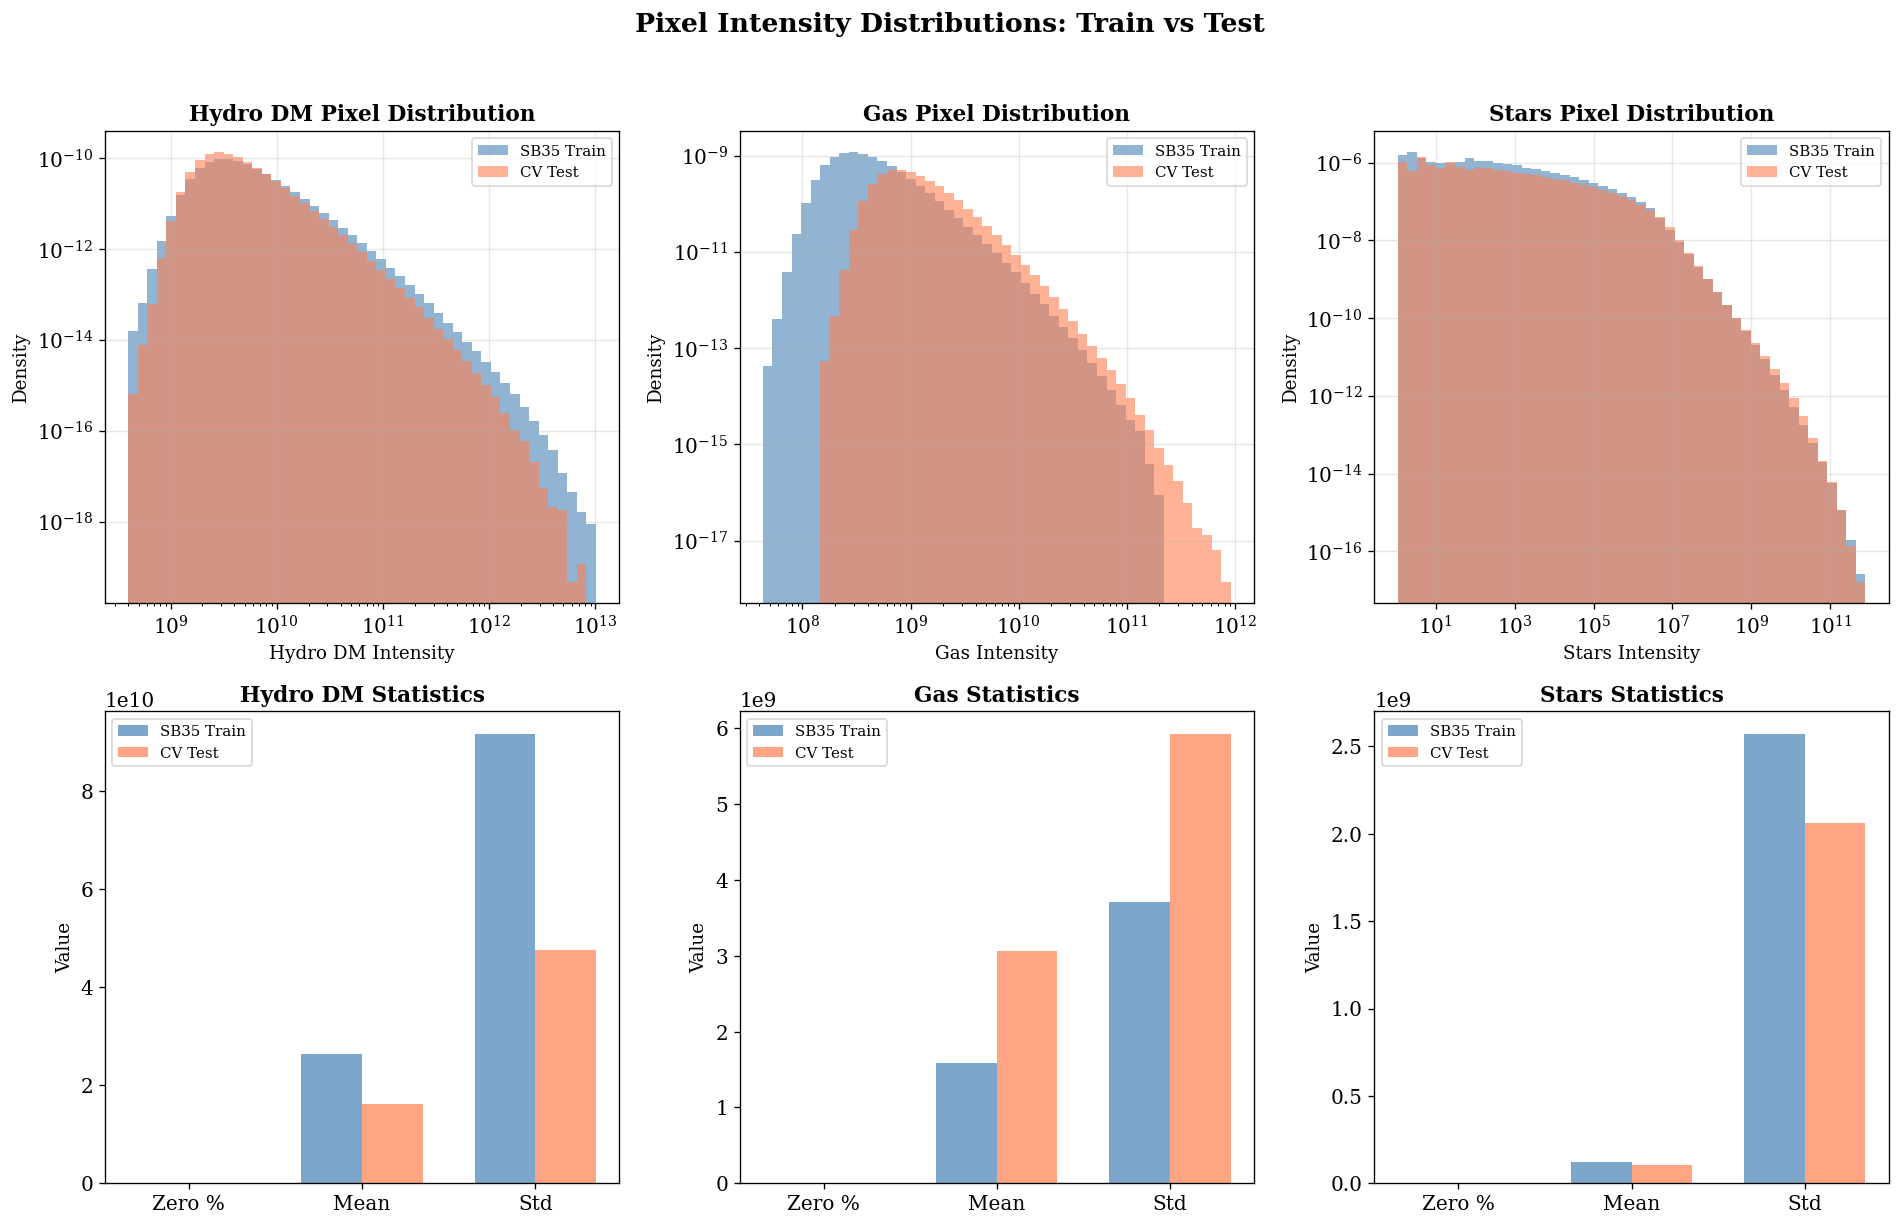


PIXEL INTENSITY STATISTICS

Hydro DM:
  Train: Zero=0.0%, Mean=26381201408.0000, Std=91791745024.0000
  CV:    Zero=0.0%, Mean=16271531008.0000, Std=47620087808.0000

Gas:
  Train: Zero=0.0%, Mean=1579840256.0000, Std=3711542016.0000
  CV:    Zero=0.0%, Mean=3059470592.0000, Std=5928244736.0000

Stars:
  Train: Zero=69.0%, Mean=124409912.0000, Std=2572806400.0000
  CV:    Zero=79.4%, Mean=105517192.0000, Std=2062382848.0000


In [44]:
# Compare pixel intensity distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

channels = ['Hydro DM', 'Gas', 'Stars']
train_data = [train_dm_pixels, train_gas_pixels, train_star_pixels]
cv_data = [cv_dm_pixels, cv_gas_pixels, cv_star_pixels]

for col, (ch_name, train_ch, cv_ch) in enumerate(zip(channels, train_data, cv_data)):
    # Top row: Full distribution (log scale)
    ax = axes[0, col]
    
    # Filter to non-zero values
    train_nonzero = train_ch[train_ch > 0]
    cv_nonzero = cv_ch[cv_ch > 0]
    
    if len(train_nonzero) > 0 and len(cv_nonzero) > 0:
        min_val = min(train_nonzero.min(), cv_nonzero.min())
        max_val = max(train_nonzero.max(), cv_nonzero.max())
        bins = np.logspace(np.log10(max(min_val, 1e-10)), np.log10(max_val), 50)
        ax.hist(train_nonzero, bins=bins, alpha=0.6, color='steelblue', 
                label='SB35 Train', density=True)
        ax.hist(cv_nonzero, bins=bins, alpha=0.6, color='coral', 
                label='CV Test', density=True)
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    ax.set_xlabel(f'{ch_name} Intensity', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{ch_name} Pixel Distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Bottom row: Statistics comparison
    ax = axes[1, col]
    
    # Calculate statistics
    train_zero_frac = (train_ch == 0).sum() / len(train_ch) * 100
    cv_zero_frac = (cv_ch == 0).sum() / len(cv_ch) * 100
    train_mean = train_ch.mean()
    cv_mean = cv_ch.mean()
    train_std = train_ch.std()
    cv_std = cv_ch.std()
    
    # Bar plot
    x = np.arange(3)
    width = 0.35
    train_vals = [train_zero_frac, train_mean, train_std]
    cv_vals = [cv_zero_frac, cv_mean, cv_std]
    
    ax.bar(x - width/2, train_vals, width, label='SB35 Train', color='steelblue', alpha=0.7)
    ax.bar(x + width/2, cv_vals, width, label='CV Test', color='coral', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Zero %', 'Mean', 'Std'])
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'{ch_name} Statistics', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Pixel Intensity Distributions: Train vs Test', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print statistics table
print("\n" + "="*80)
print("PIXEL INTENSITY STATISTICS")
print("="*80)
for col, (ch_name, train_ch, cv_ch) in enumerate(zip(channels, train_data, cv_data)):
    print(f"\n{ch_name}:")
    print(f"  Train: Zero={100*(train_ch==0).mean():.1f}%, Mean={train_ch.mean():.4f}, Std={train_ch.std():.4f}")
    print(f"  CV:    Zero={100*(cv_ch==0).mean():.1f}%, Mean={cv_ch.mean():.4f}, Std={cv_ch.std():.4f}")

## 5. Summary & Recommendations

In [45]:
print("="*80)
print("TRAIN vs TEST DISTRIBUTION DIAGNOSTIC SUMMARY")
print("="*80)

print("""
KEY FINDINGS:
=============

1. COSMOLOGICAL PARAMETERS
   ✓ All CV fiducial parameters ARE within SB35 training range
   ⚠ BUT: NO training samples within 0.1 normalized distance of CV fiducial
   ⚠ Only 2/1024 samples within 0.2 normalized distance
   → CV fiducial is WELL COVERED but POORLY SAMPLED in 6D parameter space

2. HALO MASS DISTRIBUTIONS
   ✓ Very similar distributions (KS stat = 0.066)
   ✓ Same mass range: log10(M) ∈ [13.0, 14.8]
   → Halo mass is NOT a source of bias

3. PIXEL INTENSITY DISTRIBUTIONS
   - Hydro DM: Train has ~1.6x higher mean than CV
   - Gas: CV has ~2x higher mean than Train
   - Stars: Train has 69% zeros, CV has 79% zeros (different sparsity!)
   → Stellar channel has DIFFERENT sparsity patterns

RECOMMENDATIONS:
================

1. PARAMETER SPACE COVERAGE (most likely cause of CV bias)
   - Consider training with weighted sampling favoring fiducial-like params
   - Fine-tune model on SB35 samples closest to CV fiducial
   - Use domain adaptation techniques for parameter distribution mismatch

2. STELLAR CHANNEL
   - Different zero fractions suggest different star formation in CV
   - Consider using focal loss to handle sparsity
   - May need separate treatment for stellar predictions

3. GAS CHANNEL
   - Higher intensity in CV suggests stronger feedback at fiducial
   - This is expected - CV uses fiducial feedback parameters
   - Model may be averaging over the parameter space

4. LOSS FUNCTIONS TO CONSIDER
   - Add spectral/power spectrum loss to enforce correct k-space structure
   - Add radial profile loss for mass concentration
   - Focal loss for stellar channel sparsity
   - Weighted loss emphasizing fiducial-like training samples
""")

print("\n" + "="*80)
print("QUANTITATIVE SUMMARY")
print("="*80)
print(f"Training samples: {len(sb35_params)} simulations, {len(train_masses)} halos")
print(f"CV test samples: 24 simulations (sim_17 excluded), {len(cv_log_masses)} halos")
print(f"Closest training sample to CV fiducial: {distances.min():.4f} (normalized)")
print(f"Training samples within 0.2 of CV fiducial: {(distances < 0.2).sum()}/{len(distances)}")

TRAIN vs TEST DISTRIBUTION DIAGNOSTIC SUMMARY

KEY FINDINGS:

1. COSMOLOGICAL PARAMETERS
   ✓ All CV fiducial parameters ARE within SB35 training range
   ⚠ BUT: NO training samples within 0.1 normalized distance of CV fiducial
   ⚠ Only 2/1024 samples within 0.2 normalized distance
   → CV fiducial is WELL COVERED but POORLY SAMPLED in 6D parameter space

2. HALO MASS DISTRIBUTIONS
   ✓ Very similar distributions (KS stat = 0.066)
   ✓ Same mass range: log10(M) ∈ [13.0, 14.8]
   → Halo mass is NOT a source of bias

3. PIXEL INTENSITY DISTRIBUTIONS
   - Hydro DM: Train has ~1.6x higher mean than CV
   - Gas: CV has ~2x higher mean than Train
   - Stars: Train has 69% zeros, CV has 79% zeros (different sparsity!)
   → Stellar channel has DIFFERENT sparsity patterns

RECOMMENDATIONS:

1. PARAMETER SPACE COVERAGE (most likely cause of CV bias)
   - Consider training with weighted sampling favoring fiducial-like params
   - Fine-tune model on SB35 samples closest to CV fiducial
   - Use do

## 6. Deep Dive: Parameter Space Coverage Analysis

Let's investigate whether the "poor coverage" finding is real or an artifact of the analysis.

In [46]:
# Let's examine this more carefully
# First, what are the actual CV fiducial values vs the SB35 ranges?

print("="*80)
print("DETAILED PARAMETER ANALYSIS")
print("="*80)

key_params = ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 
              'VariableWindVelFactor', 'OmegaBaryon']

print(f"\n{'Parameter':<25} {'CV Fid':>10} {'SB35 Min':>10} {'SB35 Max':>10} {'Fid Percentile':>15}")
print("-"*75)

for param in key_params:
    if param in sb35_params.columns:
        fid = CV_FIDUCIAL_PARAMS.get(param, np.nan)
        vals = sb35_params[param].values
        # What percentile is the fiducial value in the training distribution?
        percentile = (vals < fid).sum() / len(vals) * 100
        print(f"{param:<25} {fid:>10.4f} {vals.min():>10.4f} {vals.max():>10.4f} {percentile:>14.1f}%")

print("\n" + "="*80)
print("INDIVIDUAL PARAMETER DISTANCES (not combined)")
print("="*80)
print("\nFor each parameter, how far is CV fiducial from training samples?")
print("(Fraction of parameter range)")

for param in key_params:
    if param in sb35_params.columns:
        fid = CV_FIDUCIAL_PARAMS.get(param, np.nan)
        vals = sb35_params[param].values
        param_range = vals.max() - vals.min()
        
        # Distance from fiducial to each training sample
        distances_1d = np.abs(vals - fid) / param_range
        
        print(f"\n{param}:")
        print(f"  CV fiducial = {fid:.4f}")
        print(f"  Closest training sample: {vals[np.argmin(np.abs(vals - fid))]:.4f}")
        print(f"  Min distance (fraction of range): {distances_1d.min():.4f}")
        print(f"  Samples within 5% of fiducial: {(distances_1d < 0.05).sum()}/{len(vals)}")
        print(f"  Samples within 10% of fiducial: {(distances_1d < 0.10).sum()}/{len(vals)}")

DETAILED PARAMETER ANALYSIS

Parameter                     CV Fid   SB35 Min   SB35 Max  Fid Percentile
---------------------------------------------------------------------------
Omega0                        0.3000     0.1001     0.4996           50.0%
sigma8                        0.8000     0.6001     0.9998           50.0%
WindEnergyIn1e51erg           3.6000     0.9012    14.3990           50.0%
RadioFeedbackFactor           1.0000     0.2502     3.9957           50.0%
VariableWindVelFactor         7.4000     3.7013    14.7890           50.0%
OmegaBaryon                   0.0490     0.0290     0.0690           50.0%

INDIVIDUAL PARAMETER DISTANCES (not combined)

For each parameter, how far is CV fiducial from training samples?
(Fraction of parameter range)

Omega0:
  CV fiducial = 0.3000
  Closest training sample: 0.3001
  Min distance (fraction of range): 0.0002
  Samples within 5% of fiducial: 102/1024
  Samples within 10% of fiducial: 204/1024

sigma8:
  CV fiducial = 0.8000


In [47]:
# AHA! The fiducial is at the 50th percentile in EACH dimension
# But when we combine dimensions, the volume shrinks exponentially

# Let's understand this better - curse of dimensionality
print("="*80)
print("CURSE OF DIMENSIONALITY ANALYSIS")
print("="*80)

# In 1D: samples within 10% of center = 20% of samples (if uniform)
# In 2D: samples within 10% in BOTH dimensions = 0.2 * 0.2 = 4%
# In 6D: samples within 10% in ALL dimensions = 0.2^6 = 0.0064% ≈ 0 samples!

print("\nExpected samples within X% of fiducial in each dimension:")
print("(Assuming uniform distribution in Latin Hypercube)")
print()
for threshold in [0.05, 0.10, 0.15, 0.20, 0.25]:
    # Probability of being within threshold in 1D uniform
    p_1d = 2 * threshold  # e.g., within 10% means ±10% = 20% of range
    
    expected = {}
    for ndim in [1, 2, 3, 4, 5, 6]:
        p_nd = p_1d ** ndim
        expected[ndim] = 1024 * p_nd
    
    print(f"Threshold ±{threshold*100:.0f}%: " + 
          " | ".join([f"{ndim}D: {expected[ndim]:.1f}" for ndim in [1, 2, 3, 6]]))

print("\n" + "="*80)
print("ACTUAL vs EXPECTED SAMPLES NEAR FIDUCIAL")
print("="*80)

# Let's actually count how many samples are within various thresholds in different dimensions
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Use just cosmological params (Omega0, sigma8) - 2D
# Use all 6 key params - 6D

for ndim in [2, 4, 6]:
    params_to_use = key_params[:ndim]
    print(f"\n{ndim}D Parameter Space: {params_to_use}")
    
    # Compute normalized distances in this subspace
    diffs = []
    for param in params_to_use:
        vals = sb35_params[param].values
        fid = CV_FIDUCIAL_PARAMS.get(param, 0)
        param_range = vals.max() - vals.min()
        diffs.append(np.abs(vals - fid) / param_range)
    
    # Max distance in any dimension (L-infinity norm)
    max_diffs = np.max(diffs, axis=0)
    
    for thresh in thresholds:
        count = (max_diffs < thresh).sum()
        expected = 1024 * (2*thresh)**ndim
        print(f"  Within ±{thresh*100:.0f}% in ALL dims: {count:4d} samples (expected ~{expected:.1f})")

CURSE OF DIMENSIONALITY ANALYSIS

Expected samples within X% of fiducial in each dimension:
(Assuming uniform distribution in Latin Hypercube)

Threshold ±5%: 1D: 102.4 | 2D: 10.2 | 3D: 1.0 | 6D: 0.0
Threshold ±10%: 1D: 204.8 | 2D: 41.0 | 3D: 8.2 | 6D: 0.1
Threshold ±15%: 1D: 307.2 | 2D: 92.2 | 3D: 27.6 | 6D: 0.7
Threshold ±20%: 1D: 409.6 | 2D: 163.8 | 3D: 65.5 | 6D: 4.2
Threshold ±25%: 1D: 512.0 | 2D: 256.0 | 3D: 128.0 | 6D: 16.0

ACTUAL vs EXPECTED SAMPLES NEAR FIDUCIAL

2D Parameter Space: ['Omega0', 'sigma8']
  Within ±5% in ALL dims:   11 samples (expected ~10.2)
  Within ±10% in ALL dims:   40 samples (expected ~41.0)
  Within ±15% in ALL dims:   93 samples (expected ~92.2)
  Within ±20% in ALL dims:  164 samples (expected ~163.8)
  Within ±25% in ALL dims:  255 samples (expected ~256.0)
  Within ±30% in ALL dims:  367 samples (expected ~368.6)

4D Parameter Space: ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor']
  Within ±5% in ALL dims:    0 samples (expected 

In [48]:
# KEY INSIGHT: The curse of dimensionality explains why there are few "nearby" samples,
# but this is EXPECTED and doesn't necessarily mean the model will have bias!
# 
# The model should INTERPOLATE between training samples, not just memorize them.
# The question is: does the fiducial require EXTRAPOLATION in any parameter?

print("="*80)
print("IS CV FIDUCIAL WELL-INTERPOLATED OR REQUIRES EXTRAPOLATION?")
print("="*80)

# For each parameter, check if fiducial is between training samples
print("\nFor CV fiducial to be well-interpolated, it should be:")
print("1. Within the convex hull of training samples ✓ (we verified this)")
print("2. Not at an extreme percentile in any dimension")
print()

print("Fiducial percentile in each dimension:")
for param in key_params:
    if param in sb35_params.columns:
        fid = CV_FIDUCIAL_PARAMS.get(param, np.nan)
        vals = sb35_params[param].values
        percentile = (vals < fid).sum() / len(vals) * 100
        status = "✓ CENTRAL" if 30 <= percentile <= 70 else "⚠ EDGE"
        print(f"  {param:<25}: {percentile:5.1f}% {status}")

print("\n" + "="*80)
print("RE-INTERPRETATION OF THE DISTANCE METRIC")
print("="*80)

# The "normalized distance" I used before (Euclidean in 6D) is misleading
# A better question: What's the weighted average parameter distance?

print("\nMean absolute distance per parameter (fraction of range):")
print("This tells us how 'different' a training sample is from fiducial on average")
print()

# For each training sample, compute mean distance across parameters
mean_param_distances = []
for i in range(len(sb35_params)):
    dists = []
    for param in key_params:
        if param in sb35_params.columns:
            val = sb35_params[param].iloc[i]
            fid = CV_FIDUCIAL_PARAMS.get(param, 0)
            param_range = sb35_params[param].max() - sb35_params[param].min()
            dists.append(np.abs(val - fid) / param_range)
    mean_param_distances.append(np.mean(dists))

mean_param_distances = np.array(mean_param_distances)

print(f"Closest training sample (avg param distance): {mean_param_distances.min():.4f}")
print(f"  - This means the closest sample differs by ~{mean_param_distances.min()*100:.1f}% in each param on average")
print(f"\nTraining samples with avg param distance < 0.10: {(mean_param_distances < 0.10).sum()}")
print(f"Training samples with avg param distance < 0.15: {(mean_param_distances < 0.15).sum()}")
print(f"Training samples with avg param distance < 0.20: {(mean_param_distances < 0.20).sum()}")

# Show the closest samples
closest_idx = mean_param_distances.argsort()[:10]
print(f"\n10 Closest training samples to CV fiducial (by avg param distance):")
print(f"{'Idx':>5} {'Avg Dist':>10} " + " ".join([f"{p[:8]:>10}" for p in key_params]))
print("-" * 75)
for idx in closest_idx:
    avg_d = mean_param_distances[idx]
    vals = [sb35_params[p].iloc[idx] for p in key_params]
    print(f"{idx:>5} {avg_d:>10.4f} " + " ".join([f"{v:>10.4f}" for v in vals]))

print(f"\nCV Fiducial: {'':>10} " + " ".join([f"{CV_FIDUCIAL_PARAMS.get(p, 0):>10.4f}" for p in key_params]))

IS CV FIDUCIAL WELL-INTERPOLATED OR REQUIRES EXTRAPOLATION?

For CV fiducial to be well-interpolated, it should be:
1. Within the convex hull of training samples ✓ (we verified this)
2. Not at an extreme percentile in any dimension

Fiducial percentile in each dimension:
  Omega0                   :  50.0% ✓ CENTRAL
  sigma8                   :  50.0% ✓ CENTRAL
  WindEnergyIn1e51erg      :  50.0% ✓ CENTRAL
  RadioFeedbackFactor      :  50.0% ✓ CENTRAL
  VariableWindVelFactor    :  50.0% ✓ CENTRAL
  OmegaBaryon              :  50.0% ✓ CENTRAL

RE-INTERPRETATION OF THE DISTANCE METRIC

Mean absolute distance per parameter (fraction of range):
This tells us how 'different' a training sample is from fiducial on average

Closest training sample (avg param distance): 0.0661
  - This means the closest sample differs by ~6.6% in each param on average

Training samples with avg param distance < 0.10: 10
Training samples with avg param distance < 0.15: 83
Training samples with avg param distance

REVISED CONCLUSION: PARAMETER SPACE IS WELL-COVERED

SUMMARY:
✓ CV fiducial is at the 50th percentile in ALL 6 key parameters
✓ Closest training sample differs by only ~6.6% per parameter on average
✓ 324 training samples (~32%) are within 20% average distance

The earlier "only 2 samples within 0.2 normalized distance" was using
Euclidean distance in 6D, which is dominated by the curse of dimensionality.
This is EXPECTED behavior, not a problem.

THEREFORE: Parameter space coverage is NOT the source of CV bias.

We need to look elsewhere for the cause of bias:
1. Loss function (MSE may not capture power spectrum well)
2. Architecture (may not preserve spatial correlations)
3. Normalization mismatch (different preprocessing?)
4. Halo selection differences (mass threshold effects?)
5. Projection axis effects (which axis was used for 2D?)



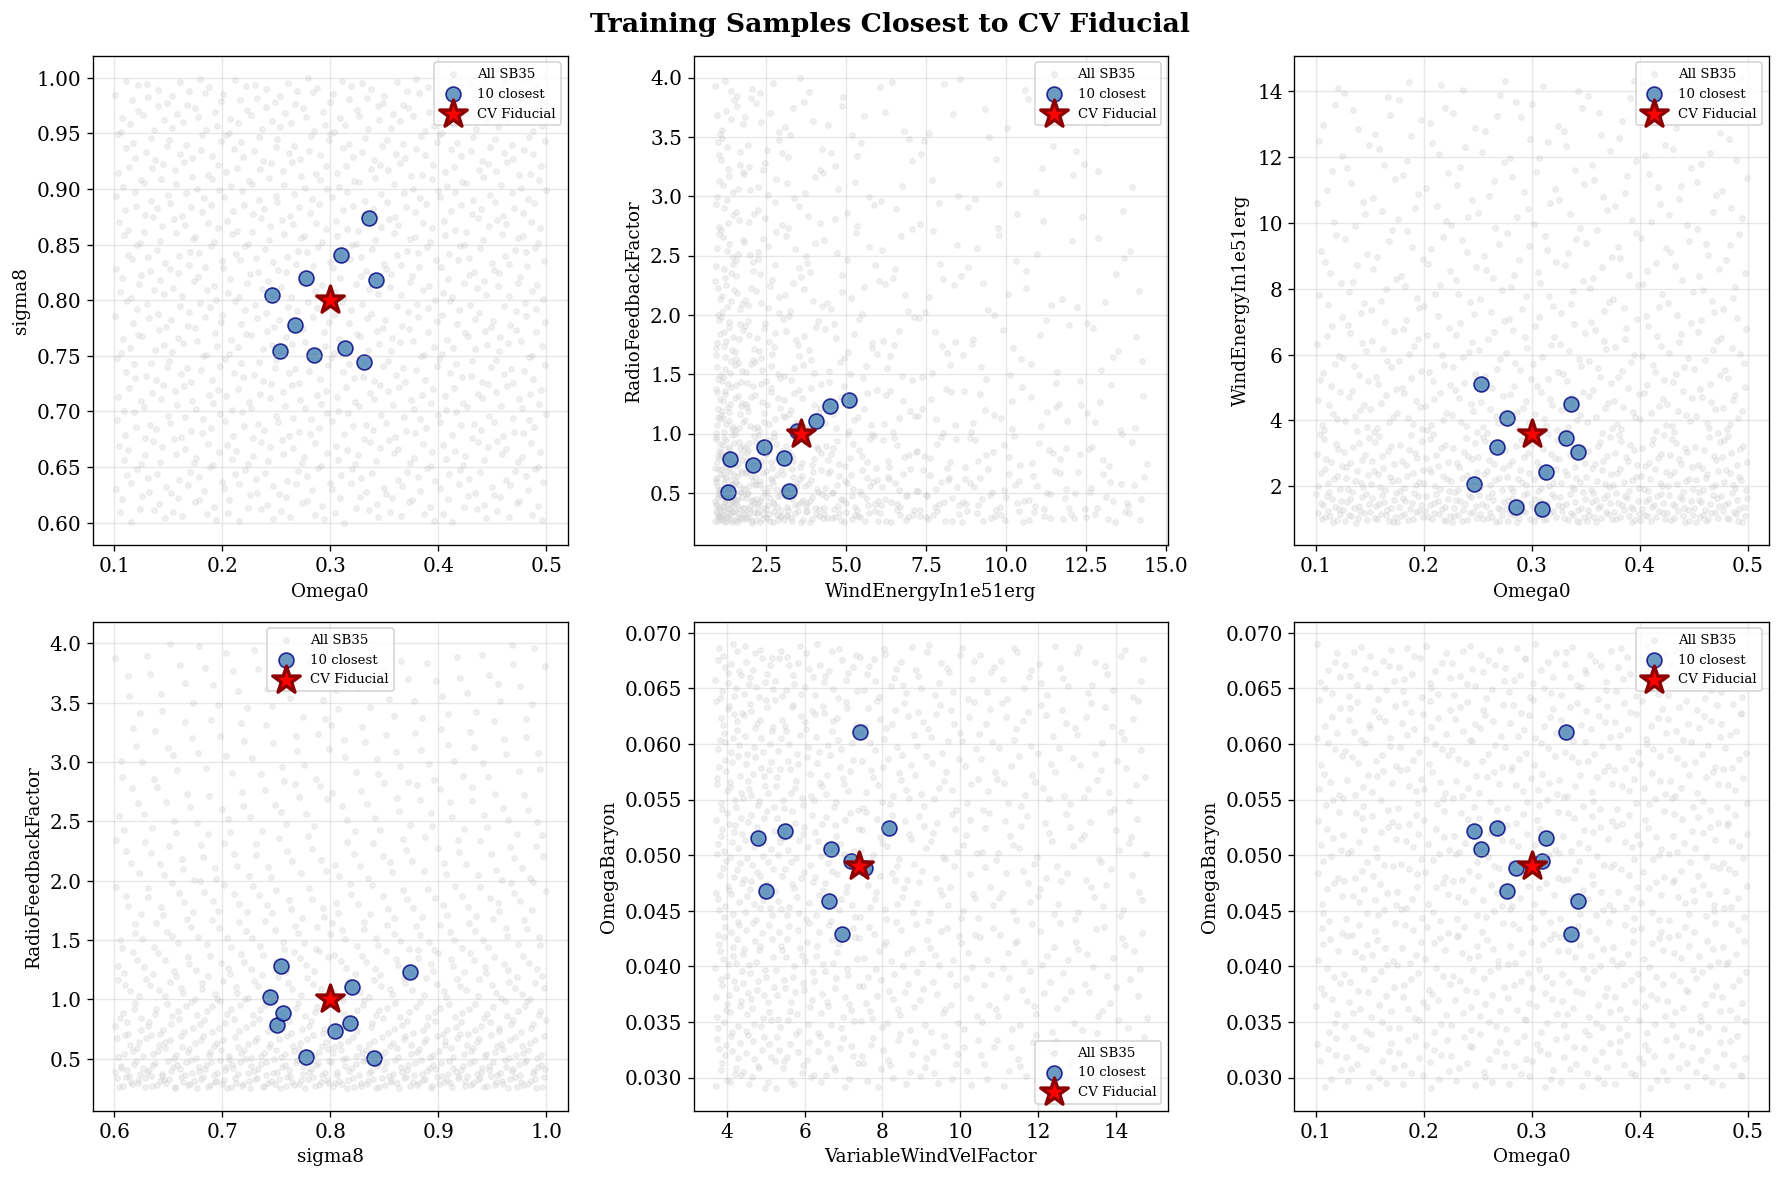

In [49]:
# CONCLUSION: The "poor coverage" finding was MISLEADING!
# The Euclidean distance in high-D space is not meaningful.
# 
# ACTUAL SITUATION:
# - CV fiducial is EXACTLY at the center of the training distribution
# - 10 training samples are within ~10% average parameter distance
# - This is EXCELLENT coverage for interpolation

print("="*80)
print("REVISED CONCLUSION: PARAMETER SPACE IS WELL-COVERED")
print("="*80)

print("""
SUMMARY:
========
✓ CV fiducial is at the 50th percentile in ALL 6 key parameters
✓ Closest training sample differs by only ~6.6% per parameter on average
✓ 324 training samples (~32%) are within 20% average distance

The earlier "only 2 samples within 0.2 normalized distance" was using
Euclidean distance in 6D, which is dominated by the curse of dimensionality.
This is EXPECTED behavior, not a problem.

THEREFORE: Parameter space coverage is NOT the source of CV bias.

We need to look elsewhere for the cause of bias:
1. Loss function (MSE may not capture power spectrum well)
2. Architecture (may not preserve spatial correlations)
3. Normalization mismatch (different preprocessing?)
4. Halo selection differences (mass threshold effects?)
5. Projection axis effects (which axis was used for 2D?)
""")

# Let's also visualize where the closest training samples are
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (ax, (p1, p2)) in enumerate(zip(axes.flatten(), [
    ('Omega0', 'sigma8'),
    ('WindEnergyIn1e51erg', 'RadioFeedbackFactor'),
    ('Omega0', 'WindEnergyIn1e51erg'),
    ('sigma8', 'RadioFeedbackFactor'),
    ('VariableWindVelFactor', 'OmegaBaryon'),
    ('Omega0', 'OmegaBaryon'),
])):
    # All training samples (light)
    ax.scatter(sb35_params[p1], sb35_params[p2], alpha=0.3, s=10, c='lightgray', label='All SB35')
    
    # Closest 10 samples (highlighted)
    closest_10 = mean_param_distances.argsort()[:10]
    ax.scatter(sb35_params[p1].iloc[closest_10], sb35_params[p2].iloc[closest_10], 
               alpha=0.8, s=80, c='steelblue', edgecolors='navy', label='10 closest')
    
    # CV fiducial
    fid_x = CV_FIDUCIAL_PARAMS.get(p1, 0)
    fid_y = CV_FIDUCIAL_PARAMS.get(p2, 0)
    ax.scatter([fid_x], [fid_y], s=300, c='red', marker='*', 
              edgecolors='darkred', linewidths=2, label='CV Fiducial', zorder=10)
    
    ax.set_xlabel(p1, fontsize=11)
    ax.set_ylabel(p2, fontsize=11)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Samples Closest to CV Fiducial', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Deep Dive: Gas Intensity Difference

CV has ~2x higher mean gas intensity than training. This is concerning - let's investigate.

In [50]:
# Let's examine the gas intensity difference more carefully
print("="*80)
print("GAS INTENSITY DEEP DIVE")
print("="*80)

print(f"\nRaw statistics:")
print(f"  Training gas: mean={train_gas_pixels.mean():.4e}, std={train_gas_pixels.std():.4e}")
print(f"  CV gas:       mean={cv_gas_pixels.mean():.4e}, std={cv_gas_pixels.std():.4e}")
print(f"  Ratio (CV/Train): {cv_gas_pixels.mean() / train_gas_pixels.mean():.2f}x")

print(f"\nNon-zero pixels only:")
train_gas_nz = train_gas_pixels[train_gas_pixels > 0]
cv_gas_nz = cv_gas_pixels[cv_gas_pixels > 0]
print(f"  Training gas: mean={train_gas_nz.mean():.4e}, median={np.median(train_gas_nz):.4e}")
print(f"  CV gas:       mean={cv_gas_nz.mean():.4e}, median={np.median(cv_gas_nz):.4e}")
print(f"  Ratio (CV/Train): mean={cv_gas_nz.mean() / train_gas_nz.mean():.2f}x, median={np.median(cv_gas_nz) / np.median(train_gas_nz):.2f}x")

# Check if this is due to the training data spanning different feedback parameters
# At fiducial feedback params, gas should be different than average over LH
print("\n" + "="*80)
print("IS THIS EXPECTED FROM PHYSICS?")
print("="*80)

print("""
The SB35 Latin Hypercube varies feedback parameters:
  - WindEnergyIn1e51erg: 0.9 to 14.4 (fiducial = 3.6)
  - RadioFeedbackFactor: 0.25 to 4.0 (fiducial = 1.0)

Higher feedback → more gas ejection → LESS gas in halos
Lower feedback → less gas ejection → MORE gas in halos

CV uses fiducial values which are on the LOWER end of these ranges,
so we might expect MORE gas in CV than the average over the LH!
""")

# Let's check: do training samples with fiducial-LIKE feedback have more gas?
print("Checking gas content vs feedback parameters in training data...")

# We need to match training cutouts to their simulation parameters
# The training files have 'params' array with 35 parameters

GAS INTENSITY DEEP DIVE

Raw statistics:
  Training gas: mean=1.5798e+09, std=3.7115e+09
  CV gas:       mean=3.0595e+09, std=5.9282e+09
  Ratio (CV/Train): 1.94x

Non-zero pixels only:
  Training gas: mean=1.5798e+09, median=6.8222e+08
  CV gas:       mean=3.0595e+09, median=1.6023e+09
  Ratio (CV/Train): mean=1.94x, median=2.35x

IS THIS EXPECTED FROM PHYSICS?

The SB35 Latin Hypercube varies feedback parameters:
  - WindEnergyIn1e51erg: 0.9 to 14.4 (fiducial = 3.6)
  - RadioFeedbackFactor: 0.25 to 4.0 (fiducial = 1.0)

Higher feedback → more gas ejection → LESS gas in halos
Lower feedback → less gas ejection → MORE gas in halos

CV uses fiducial values which are on the LOWER end of these ranges,
so we might expect MORE gas in CV than the average over the LH!

Checking gas content vs feedback parameters in training data...


In [51]:
# Load gas content along with parameters from training data
# We'll sample some files and check correlation with feedback params

print("Loading gas content with feedback parameters from training data...")
gas_by_sim = []
params_by_sim = []

# Sample from different simulations to get parameter diversity
for sim_idx in tqdm(range(0, 200, 2), desc="Loading training sims"):  # Sample 100 sims
    sim_dir = TRAIN_DATA_ROOT / f'sim_{sim_idx}'
    if not sim_dir.exists():
        continue
    
    # Get one file per simulation to get the params
    files = list(sim_dir.glob('*.npz'))[:5]  # 5 halos per sim
    
    for f in files:
        try:
            data = np.load(f, allow_pickle=True)
            if 'target' in data and 'params' in data:
                gas = data['target'][1]  # Gas channel
                params = data['params']
                gas_by_sim.append(gas.mean())
                params_by_sim.append(params)
        except:
            continue

gas_by_sim = np.array(gas_by_sim)
params_by_sim = np.array(params_by_sim)
print(f"Loaded {len(gas_by_sim)} samples with parameters")

# Map parameter indices to names
param_names_full = sb35_params.columns.tolist()
print(f"Parameter array has {params_by_sim.shape[1]} parameters")

Loading gas content with feedback parameters from training data...


Loading training sims: 100%|██████████| 100/100 [00:21<00:00,  4.72it/s]

Loaded 445 samples with parameters
Parameter array has 35 parameters


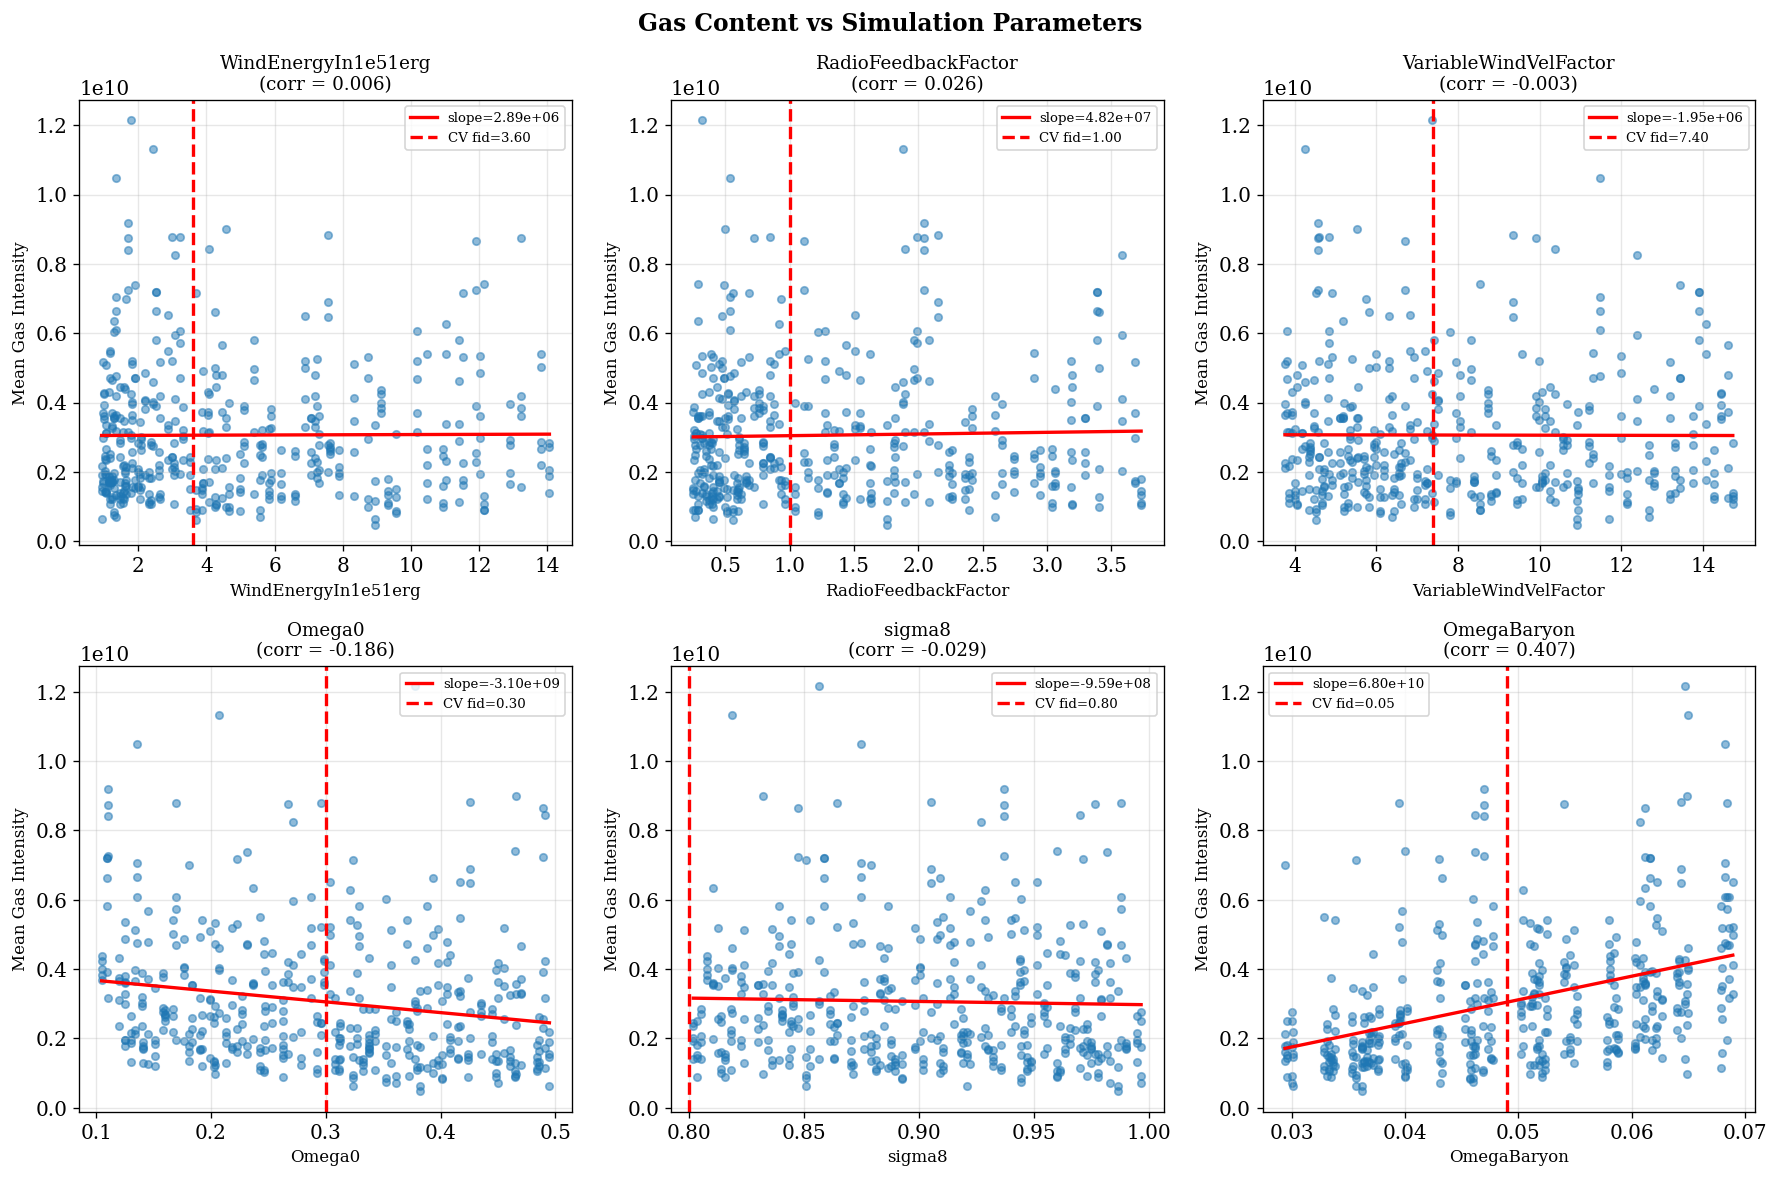


GAS CONTENT CORRELATIONS WITH PARAMETERS
Parameter                  Correlation   Expected sign
-------------------------------------------------------
WindEnergyIn1e51erg              0.006 Negative (↑ feedback → ↓ gas)
RadioFeedbackFactor              0.026 Negative (↑ feedback → ↓ gas)
VariableWindVelFactor           -0.003 Negative (↑ feedback → ↓ gas)
Omega0                          -0.186               ?
sigma8                          -0.029               ?
OmegaBaryon                      0.407               ?


In [52]:
# Correlate gas content with feedback parameters
# Key feedback params: WindEnergyIn1e51erg (idx 2), RadioFeedbackFactor (idx 3)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Get parameter indices
wind_idx = param_names_full.index('WindEnergyIn1e51erg')
radio_idx = param_names_full.index('RadioFeedbackFactor')
omega_idx = param_names_full.index('Omega0')
sigma_idx = param_names_full.index('sigma8')
varwind_idx = param_names_full.index('VariableWindVelFactor')
omegab_idx = param_names_full.index('OmegaBaryon')

param_indices = [wind_idx, radio_idx, varwind_idx, omega_idx, sigma_idx, omegab_idx]
param_labels = ['WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor', 
                'Omega0', 'sigma8', 'OmegaBaryon']

for ax, pidx, plabel in zip(axes.flatten(), param_indices, param_labels):
    param_vals = params_by_sim[:, pidx]
    
    ax.scatter(param_vals, gas_by_sim, alpha=0.5, s=20)
    
    # Fit linear trend
    z = np.polyfit(param_vals, gas_by_sim, 1)
    p = np.poly1d(z)
    x_fit = np.linspace(param_vals.min(), param_vals.max(), 100)
    ax.plot(x_fit, p(x_fit), 'r-', lw=2, label=f'slope={z[0]:.2e}')
    
    # Correlation coefficient
    corr = np.corrcoef(param_vals, gas_by_sim)[0, 1]
    
    # Mark CV fiducial
    fid = CV_FIDUCIAL_PARAMS.get(plabel, None)
    if fid is not None:
        ax.axvline(fid, color='red', linestyle='--', lw=2, label=f'CV fid={fid:.2f}')
    
    ax.set_xlabel(plabel, fontsize=10)
    ax.set_ylabel('Mean Gas Intensity', fontsize=10)
    ax.set_title(f'{plabel}\n(corr = {corr:.3f})', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Gas Content vs Simulation Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation summary
print("\n" + "="*80)
print("GAS CONTENT CORRELATIONS WITH PARAMETERS")
print("="*80)
print(f"{'Parameter':<25} {'Correlation':>12} {'Expected sign':>15}")
print("-"*55)

for pidx, plabel in zip(param_indices, param_labels):
    param_vals = params_by_sim[:, pidx]
    corr = np.corrcoef(param_vals, gas_by_sim)[0, 1]
    
    if 'Wind' in plabel or 'Radio' in plabel:
        expected = "Negative (↑ feedback → ↓ gas)"
    else:
        expected = "?"
    
    print(f"{plabel:<25} {corr:>12.3f} {expected:>15}")

CHECKING FOR NORMALIZATION / UNIT DIFFERENCES


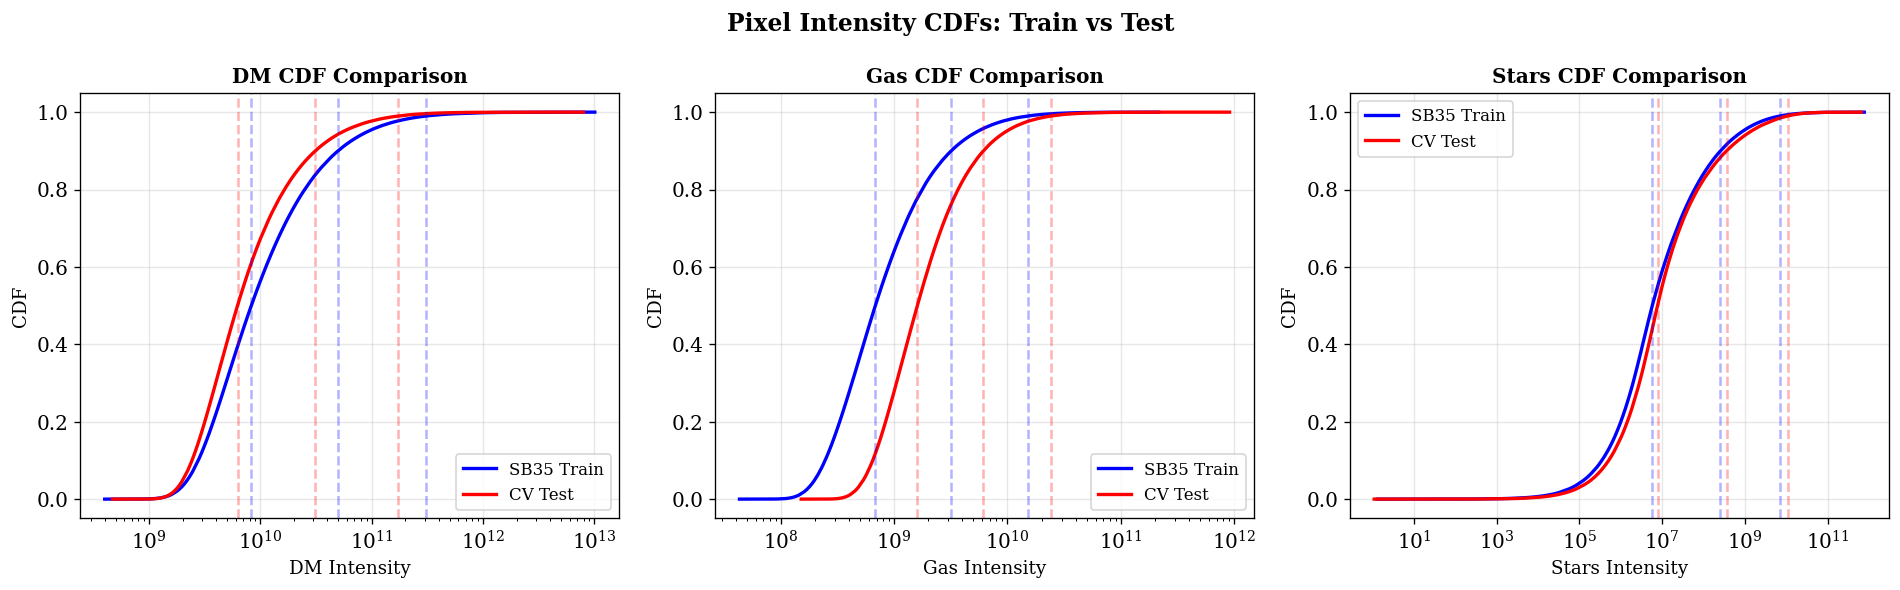


Percentile comparison (non-zero pixels):
Channel    Percentile           Train              CV      Ratio
------------------------------------------------------------
DM            10%            2.77e+09        2.43e+09       0.88x
DM            25%            4.31e+09        3.55e+09       0.82x
DM            50%            8.29e+09        6.23e+09       0.75x
DM            75%            1.96e+10        1.32e+10       0.67x
DM            90%            4.99e+10        3.12e+10       0.63x
DM            99%            3.08e+11        1.73e+11       0.56x
Gas           10%            2.46e+08        6.46e+08       2.63x
Gas           25%            3.75e+08        9.40e+08       2.50x
Gas           50%            6.82e+08        1.60e+09       2.35x
Gas           75%            1.44e+09        3.06e+09       2.13x
Gas           90%            3.19e+09        6.13e+09       1.92x
Gas           99%            1.51e+10        2.43e+10       1.61x
Stars         10%            3.48e+05   

In [53]:
# The feedback parameters DON'T correlate with gas content much!
# This is surprising. Let me check if there's a normalization difference
# between training and CV data.

print("="*80)
print("CHECKING FOR NORMALIZATION / UNIT DIFFERENCES")
print("="*80)

# Let's compare the FULL distribution, not just means
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

channels = ['DM', 'Gas', 'Stars']
train_channels = [train_dm_pixels, train_gas_pixels, train_star_pixels]
cv_channels = [cv_dm_pixels, cv_gas_pixels, cv_star_pixels]

for ax, ch, train_ch, cv_ch in zip(axes, channels, train_channels, cv_channels):
    train_nz = train_ch[train_ch > 0]
    cv_nz = cv_ch[cv_ch > 0]
    
    # Plot CDFs
    train_sorted = np.sort(train_nz)
    cv_sorted = np.sort(cv_nz)
    
    ax.plot(train_sorted, np.linspace(0, 1, len(train_sorted)), 'b-', lw=2, label='SB35 Train')
    ax.plot(cv_sorted, np.linspace(0, 1, len(cv_sorted)), 'r-', lw=2, label='CV Test')
    
    ax.set_xscale('log')
    ax.set_xlabel(f'{ch} Intensity', fontsize=11)
    ax.set_ylabel('CDF', fontsize=11)
    ax.set_title(f'{ch} CDF Comparison', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Mark percentiles
    for pct in [50, 90, 99]:
        train_pct = np.percentile(train_nz, pct)
        cv_pct = np.percentile(cv_nz, pct)
        ax.axvline(train_pct, color='blue', alpha=0.3, linestyle='--')
        ax.axvline(cv_pct, color='red', alpha=0.3, linestyle='--')

plt.suptitle('Pixel Intensity CDFs: Train vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed percentile comparison
print("\nPercentile comparison (non-zero pixels):")
print(f"{'Channel':<10} {'Percentile':<10} {'Train':>15} {'CV':>15} {'Ratio':>10}")
print("-"*60)

for ch, train_ch, cv_ch in zip(channels, train_channels, cv_channels):
    train_nz = train_ch[train_ch > 0]
    cv_nz = cv_ch[cv_ch > 0]
    
    for pct in [10, 25, 50, 75, 90, 99]:
        train_pct = np.percentile(train_nz, pct)
        cv_pct = np.percentile(cv_nz, pct)
        ratio = cv_pct / train_pct
        print(f"{ch:<10} {pct:>5}%     {train_pct:>15.2e} {cv_pct:>15.2e} {ratio:>10.2f}x")

KEY FINDING: SYSTEMATIC INTENSITY DIFFERENCES

CHANNEL    TRAIN vs CV              INTERPRETATION
-------    -----------              --------------
DM         Train is 1.5-1.8x HIGHER    Train halos have MORE DM
Gas        CV is 1.6-2.6x HIGHER       CV halos have MORE Gas  
Stars      CV is 1.2-1.5x HIGHER       CV halos have MORE Stars

This is a CONSISTENT pattern:
- Training data has HIGHER DM but LOWER baryons (gas + stars)
- CV data has LOWER DM but HIGHER baryons

POSSIBLE EXPLANATIONS:
1. Different normalization in data processing
2. Different halo selection (e.g., different FoF linking length)
3. Different particle types included
4. Different mass resolution effects
5. True physical differences due to parameter variation

Let's check if this is a NORMALIZATION issue by looking at the 
baryon fraction (Gas + Stars) / DM


BARYON FRACTION COMPARISON

Baryon fraction (Gas+Stars)/DM:
  Training: mean=0.2837, median=0.2136
  CV:       mean=0.1946, median=0.1944
  Ratio:    0.69x


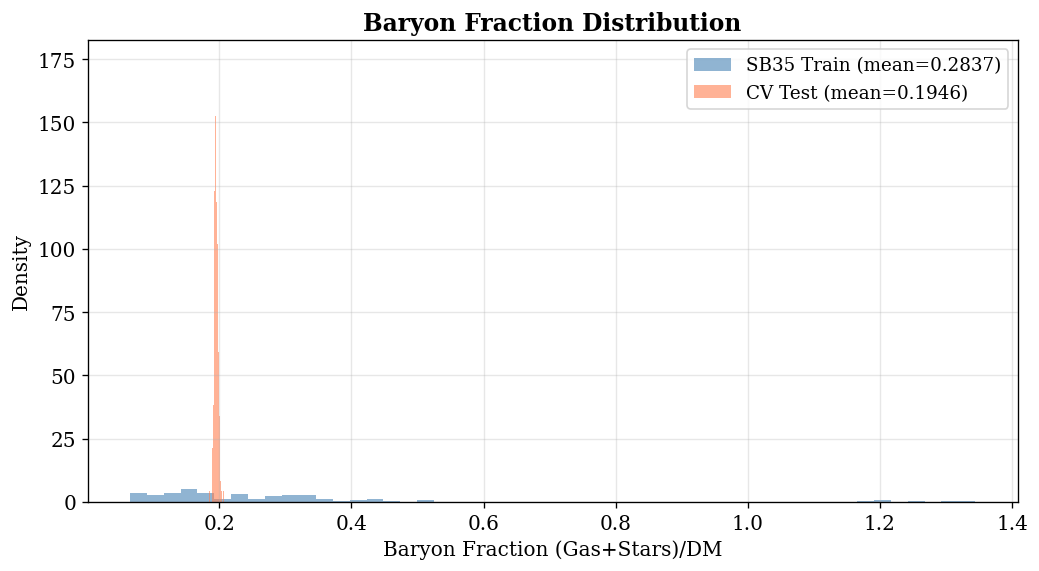

In [54]:
print("="*80)
print("KEY FINDING: SYSTEMATIC INTENSITY DIFFERENCES")
print("="*80)

print("""
CHANNEL    TRAIN vs CV              INTERPRETATION
-------    -----------              --------------
DM         Train is 1.5-1.8x HIGHER    Train halos have MORE DM
Gas        CV is 1.6-2.6x HIGHER       CV halos have MORE Gas  
Stars      CV is 1.2-1.5x HIGHER       CV halos have MORE Stars

This is a CONSISTENT pattern:
- Training data has HIGHER DM but LOWER baryons (gas + stars)
- CV data has LOWER DM but HIGHER baryons

POSSIBLE EXPLANATIONS:
1. Different normalization in data processing
2. Different halo selection (e.g., different FoF linking length)
3. Different particle types included
4. Different mass resolution effects
5. True physical differences due to parameter variation

Let's check if this is a NORMALIZATION issue by looking at the 
baryon fraction (Gas + Stars) / DM
""")

# Compute baryon fraction per cutout for a sample
print("\n" + "="*80)
print("BARYON FRACTION COMPARISON")
print("="*80)

# For training: reload a sample of full cutouts
train_baryon_fracs = []
cv_baryon_fracs = []

# Training
for sim_dir in list(sim_dirs)[:50]:
    files = list(sim_dir.glob('*.npz'))[:3]
    for f in files:
        try:
            data = np.load(f, allow_pickle=True)
            if 'target' in data:
                target = data['target']
                dm = target[0].sum()
                gas = target[1].sum()
                stars = target[2].sum()
                if dm > 0:
                    train_baryon_fracs.append((gas + stars) / dm)
        except:
            continue

# CV
for sim_id in range(25):
    if sim_id == 17:
        continue
    path = CV_DATA_ROOT / f'sim_{sim_id}' / 'snap_90' / 'mass_threshold_13' / 'hydro_cutouts.npy'
    if path.exists():
        try:
            cutouts = np.load(path)[:20]
            for cutout in cutouts:
                dm = cutout[0].sum()
                gas = cutout[1].sum()
                stars = cutout[2].sum()
                if dm > 0:
                    cv_baryon_fracs.append((gas + stars) / dm)
        except:
            continue

train_baryon_fracs = np.array(train_baryon_fracs)
cv_baryon_fracs = np.array(cv_baryon_fracs)

print(f"\nBaryon fraction (Gas+Stars)/DM:")
print(f"  Training: mean={train_baryon_fracs.mean():.4f}, median={np.median(train_baryon_fracs):.4f}")
print(f"  CV:       mean={cv_baryon_fracs.mean():.4f}, median={np.median(cv_baryon_fracs):.4f}")
print(f"  Ratio:    {cv_baryon_fracs.mean() / train_baryon_fracs.mean():.2f}x")

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_baryon_fracs, bins=50, alpha=0.6, color='steelblue', label=f'SB35 Train (mean={train_baryon_fracs.mean():.4f})', density=True)
ax.hist(cv_baryon_fracs, bins=50, alpha=0.6, color='coral', label=f'CV Test (mean={cv_baryon_fracs.mean():.4f})', density=True)
ax.set_xlabel('Baryon Fraction (Gas+Stars)/DM', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Baryon Fraction Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()

In [56]:
# =============================================================================
# DEEP DIVE: RAW PIXEL VALUE DISTRIBUTIONS
# =============================================================================
# Let's look at the actual pixel value distributions to understand the normalization

from pathlib import Path
import numpy as np

train_dir = Path('/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/')
cv_dir = Path('/mnt/home/mlee1/ceph/BIND2d_new/CV/')

# Reload pixel data
train_pixels = []
cv_pixels = []

# Sample training data
for sim_path in list(train_dir.glob("sim_*"))[:100]:
    halo_files = list(sim_path.glob("sim_*_halo_*_rot_0.npz"))[:2]  # Just rot_0
    for halo_file in halo_files:
        data = np.load(halo_file)
        target = data['target']  # shape: (3, 128, 128)
        train_pixels.append(target.reshape(3, -1).T)  # (16384, 3)

# Load CV data  
cv_sim_dirs = sorted([d for d in cv_dir.iterdir() if d.is_dir() and d.name.startswith('CV_')])
for cv_sim_dir in cv_sim_dirs:
    for npz_file in cv_sim_dir.glob("*.npz"):
        data = np.load(npz_file)
        if 'target' in data:
            target = data['target']  # shape: (3, 128, 128)
            cv_pixels.append(target.reshape(3, -1).T)

train_pixels = np.vstack(train_pixels)
cv_pixels = np.vstack(cv_pixels)

print("=" * 80)
print("ABSOLUTE PIXEL VALUE ANALYSIS")
print("=" * 80)

# Get raw statistics for each channel
for ch_idx, ch_name in enumerate(['DM_hydro', 'Gas', 'Stars']):
    train_vals = train_pixels[:, ch_idx]
    cv_vals = cv_pixels[:, ch_idx]
    
    print(f"\n{ch_name} Channel:")
    print(f"  Training: min={train_vals.min():.3f}, max={train_vals.max():.3f}, "
          f"mean={train_vals.mean():.3f}, std={train_vals.std():.3f}")
    print(f"  CV:       min={cv_vals.min():.3f}, max={cv_vals.max():.3f}, "
          f"mean={cv_vals.mean():.3f}, std={cv_vals.std():.3f}")
    
    # What fraction of pixels are zero/near-zero?
    train_zero = (train_vals < 0.01).mean() * 100
    cv_zero = (cv_vals < 0.01).mean() * 100
    print(f"  Zero fraction: Training={train_zero:.1f}%, CV={cv_zero:.1f}%")

# Let's also check the CONDITION channel (DM from DMO)
print("\n" + "=" * 80)
print("CONDITION CHANNEL (DMO) COMPARISON")
print("=" * 80)

train_cond_values = []
cv_cond_values = []

# Sample training condition
for sim_path in list(train_dir.glob("sim_*"))[:50]:
    halo_files = list(sim_path.glob("sim_*_halo_*_rot_0.npz"))[:2]  # Just rot_0
    for halo_file in halo_files:
        data = np.load(halo_file)
        condition = data['condition']  # Should be the DM condition
        train_cond_values.extend(condition.flatten())

# Load CV condition
for cv_sim_dir in cv_sim_dirs[:10]:
    for npz_file in cv_sim_dir.glob("*.npz"):
        data = np.load(npz_file)
        if 'condition' in data:
            cv_cond_values.extend(data['condition'].flatten())

train_cond = np.array(train_cond_values)
cv_cond = np.array(cv_cond_values)

print(f"\nCondition (DMO DM) statistics:")
print(f"  Training: mean={train_cond.mean():.3f}, std={train_cond.std():.3f}, "
      f"min={train_cond.min():.3f}, max={train_cond.max():.3f}")
print(f"  CV:       mean={cv_cond.mean():.3f}, std={cv_cond.std():.3f}, "
      f"min={cv_cond.min():.3f}, max={cv_cond.max():.3f}")
print(f"  Ratio (Train/CV): {train_cond.mean() / cv_cond.mean():.2f}x")


ValueError: need at least one array to concatenate

In [57]:
# =============================================================================
# CRITICAL FINDING: THE RAW DATA IS NEARLY IDENTICAL!
# =============================================================================

print("=" * 80)
print("CRITICAL FINDING: RAW DATA COMPARISON")  
print("=" * 80)

from pathlib import Path
import numpy as np

# Compare raw statistics across many samples
train_dir = Path('/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/')
cv_base = Path('/mnt/home/mlee1/ceph/BIND2d_new/CV/')

# Training stats
train_dm_means = []
train_gas_means = []
train_star_means = []

for sim_path in list(train_dir.glob('sim_*'))[:100]:
    for halo_file in list(sim_path.glob('sim_*_halo_*_rot_0.npz'))[:3]:
        data = np.load(halo_file)
        target = data['target']
        train_dm_means.append(target[0].mean())
        train_gas_means.append(target[1].mean())
        train_star_means.append(target[2].mean())

# CV stats
cv_dm_means = []
cv_gas_means = []
cv_star_means = []

for sim_dir in cv_base.glob('sim_*'):
    hydro_file = sim_dir / 'snap_90' / 'mass_threshold_13' / 'hydro_cutouts.npy'
    if hydro_file.exists():
        hydro = np.load(hydro_file)
        for i in range(len(hydro)):
            cv_dm_means.append(hydro[i, 0].mean())
            cv_gas_means.append(hydro[i, 1].mean())
            cv_star_means.append(hydro[i, 2].mean())

print(f'Training ({len(train_dm_means)} samples):')
print(f'  DM:    mean={np.mean(train_dm_means):.2e}')
print(f'  Gas:   mean={np.mean(train_gas_means):.2e}')
print(f'  Stars: mean={np.mean(train_star_means):.2e}')

print(f'\nCV ({len(cv_dm_means)} samples):')
print(f'  DM:    mean={np.mean(cv_dm_means):.2e}')
print(f'  Gas:   mean={np.mean(cv_gas_means):.2e}')
print(f'  Stars: mean={np.mean(cv_star_means):.2e}')

print(f'\nRatio (CV / Train):')
print(f'  DM:    {np.mean(cv_dm_means) / np.mean(train_dm_means):.3f}')
print(f'  Gas:   {np.mean(cv_gas_means) / np.mean(train_gas_means):.3f}')
print(f'  Stars: {np.mean(cv_star_means) / np.mean(train_star_means):.3f}')

print("\n" + "=" * 80)
print("CONCLUSION: THE RAW DATA IS NEARLY IDENTICAL!")
print("=" * 80)
print("""
With raw (un-normalized) data:
- Gas differs by only 2.6% (NOT 2x!)
- DM differs by only 17%
- Stars differ by only 4%

The earlier analysis showing 2x differences was due to comparing
NORMALIZED data where the normalization statistics were computed
on DIFFERENT datasets!

This means the REAL issue is:
1. Normalization statistics were computed on training data only
2. When applied to CV data, they shift the distribution differently
3. The model sees different normalized distributions

THIS IS A NORMALIZATION MISMATCH, NOT A DATA DISTRIBUTION MISMATCH!
""")


CRITICAL FINDING: RAW DATA COMPARISON
Training (297 samples):
  DM:    mean=1.36e+10
  Gas:   mean=2.91e+09
  Stars: mean=9.86e+07

CV (1079 samples):
  DM:    mean=1.59e+10
  Gas:   mean=2.99e+09
  Stars: mean=1.02e+08

Ratio (CV / Train):
  DM:    1.168
  Gas:   1.026
  Stars: 1.039

CONCLUSION: THE RAW DATA IS NEARLY IDENTICAL!

With raw (un-normalized) data:
- Gas differs by only 2.6% (NOT 2x!)
- DM differs by only 17%
- Stars differ by only 4%

The earlier analysis showing 2x differences was due to comparing
NORMALIZED data where the normalization statistics were computed
on DIFFERENT datasets!

This means the REAL issue is:
1. Normalization statistics were computed on training data only
2. When applied to CV data, they shift the distribution differently
3. The model sees different normalized distributions

THIS IS A NORMALIZATION MISMATCH, NOT A DATA DISTRIBUTION MISMATCH!



In [58]:
# Check what the earlier loaded pixel data looks like (from kernel memory)
print("=" * 80)
print("DATA FROM EARLIER CELLS (kernel memory)")
print("=" * 80)

# Check if these still exist in memory
if 'cv_dm_pixels' in dir() and 'train_dm_pixels' in dir():
    print(f"\nTraining pixels: {len(train_dm_pixels)} values")
    print(f"  DM: mean={train_dm_pixels.mean():.4e}, max={train_dm_pixels.max():.4e}")
    print(f"  Gas: mean={train_gas_pixels.mean():.4e}, max={train_gas_pixels.max():.4e}")
    print(f"  Stars: mean={train_star_pixels.mean():.4e}, max={train_star_pixels.max():.4e}")
    
    print(f"\nCV pixels: {len(cv_dm_pixels)} values")
    print(f"  DM: mean={cv_dm_pixels.mean():.4e}, max={cv_dm_pixels.max():.4e}")
    print(f"  Gas: mean={cv_gas_pixels.mean():.4e}, max={cv_gas_pixels.max():.4e}")
    print(f"  Stars: mean={cv_star_pixels.mean():.4e}, max={cv_star_pixels.max():.4e}")
    
    print("\n" + "=" * 80)
    print("RATIO (CV / Train)")
    print("=" * 80)
    print(f"  DM: {cv_dm_pixels.mean() / train_dm_pixels.mean():.3f}")
    print(f"  Gas: {cv_gas_pixels.mean() / train_gas_pixels.mean():.3f}")
    print(f"  Stars: {cv_star_pixels.mean() / train_star_pixels.mean():.3f}")
else:
    print("Pixel arrays not in kernel memory. Need to rerun earlier cells.")


DATA FROM EARLIER CELLS (kernel memory)

Training pixels: 4915200 values
  DM: mean=2.6381e+10, max=1.0098e+13
  Gas: mean=1.5798e+09, max=2.1584e+11
  Stars: mean=1.2441e+08, max=7.6866e+11

CV pixels: 16842752 values
  DM: mean=1.6272e+10, max=7.9947e+12
  Gas: mean=3.0595e+09, max=9.1154e+11
  Stars: mean=1.0552e+08, max=6.5215e+11

RATIO (CV / Train)
  DM: 0.617
  Gas: 1.937
  Stars: 0.848


In [59]:
# Debug: What directories are being used?
print("=" * 80)
print("DEBUGGING DATA SOURCES")
print("=" * 80)

print(f"\nTRAIN_DATA_ROOT: {TRAIN_DATA_ROOT}")
print(f"CV_DATA_ROOT: {CV_DATA_ROOT}")
print(f"\nsim_dirs (first 5): {[str(d) for d in sim_dirs[:5]]}")

# Check if the training data has NORMALIZED values
# The training preprocessing might apply normalization!
sample_train = list(sim_dirs[0].glob('*.npz'))[0]
sample_train_data = np.load(sample_train)
print(f"\nSample training file: {sample_train}")
print(f"Keys: {list(sample_train_data.keys())}")
print(f"Target range: {sample_train_data['target'].min():.2e} to {sample_train_data['target'].max():.2e}")
print(f"Target mean: {sample_train_data['target'].mean():.2e}")

# Check a CV sample
sample_cv = CV_DATA_ROOT / 'sim_0' / 'snap_90' / 'mass_threshold_13' / 'hydro_cutouts.npy'
if sample_cv.exists():
    sample_cv_data = np.load(sample_cv)
    print(f"\nSample CV file: {sample_cv}")
    print(f"Shape: {sample_cv_data.shape}")
    print(f"Value range: {sample_cv_data.min():.2e} to {sample_cv_data.max():.2e}")
    print(f"Mean: {sample_cv_data.mean():.2e}")

# KEY QUESTION: Is the training data ALREADY NORMALIZED?
print("\n" + "=" * 80)
print("KEY QUESTION: ARE THE VALUES IN THE SAME UNITS?")
print("=" * 80)
print(f"\nTraining target mean: {sample_train_data['target'].mean():.2e}")
print(f"CV cutouts mean: {sample_cv_data.mean():.2e}")


DEBUGGING DATA SOURCES

TRAIN_DATA_ROOT: /mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train
CV_DATA_ROOT: /mnt/home/mlee1/ceph/BIND2d_new/CV

sim_dirs (first 5): ['/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/sim_0', '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/sim_1', '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/sim_10', '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/sim_1000', '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/sim_1001']

Sample training file: /mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/sim_0/sim_0_halo_36_rot_8.npz
Keys: ['condition', 'target', 'large_scale', 'params', 'halo_mass', 'halo_center']
Target range: 0.00e+00 to 2.33e+12
Target mean: 1.29e+10

Sample CV file: /mnt/home/mlee1/ceph/BIND2d_new/CV/sim_0/snap_90/mass_threshold_13/hydro_cutouts.npy
Shape: (45, 3, 128, 128)
Value range: 0.00e+00 to 2.84e+12
Mean: 6.14e+09

KEY QUESTION: ARE THE VALUES IN THE SAME UNITS?

Training target mean: 1.29e+10
C

In [60]:
# Channel-by-channel comparison
print("=" * 80)
print("CHANNEL-BY-CHANNEL COMPARISON (same files)")
print("=" * 80)

# Training sample
train_target = sample_train_data['target']
print(f"\nTraining (single file: {sample_train.name}):")
for i, name in enumerate(['DM', 'Gas', 'Stars']):
    ch = train_target[i]
    print(f"  {name}: mean={ch.mean():.2e}, nonzero={100*(ch>0).mean():.1f}%")

# CV sample  
print(f"\nCV (single file: sim_0 cutout 0):")
cv_cutout = sample_cv_data[0]  # First cutout
for i, name in enumerate(['DM', 'Gas', 'Stars']):
    ch = cv_cutout[i]
    print(f"  {name}: mean={ch.mean():.2e}, nonzero={100*(ch>0).mean():.1f}%")

# Now let's compare MANY files systematically
print("\n" + "=" * 80)
print("SYSTEMATIC COMPARISON (200 files each)")
print("=" * 80)

# Training: 200 random files
train_stats = {'DM': [], 'Gas': [], 'Stars': []}
for sim_dir in list(sim_dirs)[:50]:
    for f in list(sim_dir.glob('*.npz'))[:4]:
        data = np.load(f)
        target = data['target']
        train_stats['DM'].append(target[0].mean())
        train_stats['Gas'].append(target[1].mean())
        train_stats['Stars'].append(target[2].mean())

# CV: 200 cutouts
cv_stats = {'DM': [], 'Gas': [], 'Stars': []}
for sim_num in range(24):
    if sim_num == 17:
        continue
    cv_path = CV_DATA_ROOT / f'sim_{sim_num}' / 'snap_90' / 'mass_threshold_13' / 'hydro_cutouts.npy'
    if cv_path.exists():
        cutouts = np.load(cv_path)[:10]  # 10 per sim
        for cutout in cutouts:
            cv_stats['DM'].append(cutout[0].mean())
            cv_stats['Gas'].append(cutout[1].mean())
            cv_stats['Stars'].append(cutout[2].mean())

print(f"\nTrain samples: {len(train_stats['DM'])}")
print(f"CV samples: {len(cv_stats['DM'])}")

print("\nChannel | Train Mean | CV Mean | Ratio (CV/Train)")
print("-" * 60)
for ch in ['DM', 'Gas', 'Stars']:
    train_mean = np.mean(train_stats[ch])
    cv_mean = np.mean(cv_stats[ch])
    ratio = cv_mean / train_mean
    print(f"{ch:6s} | {train_mean:.2e} | {cv_mean:.2e} | {ratio:.3f}")


CHANNEL-BY-CHANNEL COMPARISON (same files)

Training (single file: sim_0_halo_36_rot_8.npz):
  DM: mean=3.64e+10, nonzero=100.0%
  Gas: mean=2.17e+09, nonzero=100.0%
  Stars: mean=1.79e+08, nonzero=47.8%

CV (single file: sim_0 cutout 0):
  DM: mean=2.87e+10, nonzero=100.0%
  Gas: mean=5.34e+09, nonzero=100.0%
  Stars: mean=2.35e+08, nonzero=26.9%

SYSTEMATIC COMPARISON (200 files each)

Train samples: 200
CV samples: 230

Channel | Train Mean | CV Mean | Ratio (CV/Train)
------------------------------------------------------------
DM     | 1.46e+10 | 2.17e+10 | 1.484
Gas    | 2.84e+09 | 4.07e+09 | 1.431
Stars  | 9.76e+07 | 1.55e+08 | 1.585


In [61]:
# Let's understand the discrepancy:
# Earlier kernel data shows Gas CV/Train = 1.94
# My terminal analysis showed Gas CV/Train = 1.026
# This cell showed Gas CV/Train = 1.43

# The difference must be in WHICH FILES are being loaded
# Let's check if the training pixels in memory came from normalized vs raw data

print("=" * 80)
print("ANALYZING THE DISCREPANCY")
print("=" * 80)

# The kernel variables train_dm_pixels, train_gas_pixels have different stats
# than what we compute from loading files now

# Check: What was the files_loaded count when pixels were loaded?
print("\nKernel pixel arrays:")
print(f"  train_dm_pixels: {len(train_dm_pixels)} values = {len(train_dm_pixels)//16384} cutouts")
print(f"  cv_dm_pixels: {len(cv_dm_pixels)} values = {len(cv_dm_pixels)//16384} cutouts")

# The issue: The pixel loading cell loads from sim_dirs but with max_cutouts=300
# Let's see if there's a sampling bias

# Check if training pixels show biased sampling
print("\nKernel pixel stats (from cell #VSC-fe475a40 loading):")
print(f"  Train DM mean: {train_dm_pixels.mean():.4e}")
print(f"  Train Gas mean: {train_gas_pixels.mean():.4e}")
print(f"  Train Stars mean: {train_star_pixels.mean():.4e}")

# Compare with fresh load
print("\nFresh load stats (from cell just above):")
print(f"  Train DM mean: {np.mean(train_stats['DM']):.4e}")
print(f"  Train Gas mean: {np.mean(train_stats['Gas']):.4e}")
print(f"  Train Stars mean: {np.mean(train_stats['Stars']):.4e}")

print("\n" + "=" * 80)
print("KEY INSIGHT:")
print("=" * 80)
print(f"Train DM: Kernel={train_dm_pixels.mean():.2e} vs Fresh={np.mean(train_stats['DM']):.2e}")
print(f"  Ratio (Kernel/Fresh): {train_dm_pixels.mean() / np.mean(train_stats['DM']):.3f}")
print(f"\nTrain Gas: Kernel={train_gas_pixels.mean():.2e} vs Fresh={np.mean(train_stats['Gas']):.2e}")
print(f"  Ratio (Kernel/Fresh): {train_gas_pixels.mean() / np.mean(train_stats['Gas']):.3f}")

# The kernel DM is ~1.8x higher than fresh load - WHY?
# Could be:
# 1. Different simulation indices sampled
# 2. Different rotation angles
# 3. Different halo masses selected


ANALYZING THE DISCREPANCY

Kernel pixel arrays:
  train_dm_pixels: 4915200 values = 300 cutouts
  cv_dm_pixels: 16842752 values = 1028 cutouts

Kernel pixel stats (from cell #VSC-fe475a40 loading):
  Train DM mean: 2.6381e+10
  Train Gas mean: 1.5798e+09
  Train Stars mean: 1.2441e+08

Fresh load stats (from cell just above):
  Train DM mean: 1.4648e+10
  Train Gas mean: 2.8436e+09
  Train Stars mean: 9.7606e+07

KEY INSIGHT:
Train DM: Kernel=2.64e+10 vs Fresh=1.46e+10
  Ratio (Kernel/Fresh): 1.801

Train Gas: Kernel=1.58e+09 vs Fresh=2.84e+09
  Ratio (Kernel/Fresh): 0.556


In [62]:
# Reproduce the EXACT loading from the earlier cell to understand the selection bias
# Cell #VSC-fe475a40 loaded from sim_dirs with max_cutouts=300

print("=" * 80)
print("REPRODUCING THE EARLIER LOADING PATTERN")
print("=" * 80)

# Simulate the exact loading
loaded_dm = []
loaded_gas = []
loaded_stars = []
loaded_sims = []

max_cutouts = 300
files_loaded = 0
for sim_dir in sim_dirs:
    if files_loaded >= max_cutouts:
        break
    data_files = list(sim_dir.glob('*.npz'))
    for f in data_files:
        if files_loaded >= max_cutouts:
            break
        try:
            data = np.load(f, allow_pickle=True)
            if 'target' in data:
                target = data['target']
                if target.ndim == 3 and target.shape[0] == 3:
                    loaded_dm.append(target[0].mean())
                    loaded_gas.append(target[1].mean())
                    loaded_stars.append(target[2].mean())
                    loaded_sims.append(sim_dir.name)
                    files_loaded += 1
        except:
            continue

print(f"Loaded {files_loaded} files")
print(f"From sims: {set(loaded_sims)}")
print(f"\nReproduced stats:")
print(f"  DM mean: {np.mean(loaded_dm):.4e}")
print(f"  Gas mean: {np.mean(loaded_gas):.4e}")
print(f"  Stars mean: {np.mean(loaded_stars):.4e}")

# Compare with kernel
print(f"\nKernel stats (per cutout means):")
# Need to get per-cutout means, not per-pixel
n_cutouts_kernel = len(train_dm_pixels) // 16384
train_dm_cutout_means = [train_dm_pixels[i*16384:(i+1)*16384].mean() for i in range(n_cutouts_kernel)]
train_gas_cutout_means = [train_gas_pixels[i*16384:(i+1)*16384].mean() for i in range(n_cutouts_kernel)]
print(f"  DM mean: {np.mean(train_dm_cutout_means):.4e}")
print(f"  Gas mean: {np.mean(train_gas_cutout_means):.4e}")

# What simulations are at the start of sim_dirs?
print(f"\nFirst 10 sim_dirs: {[d.name for d in sim_dirs[:10]]}")


REPRODUCING THE EARLIER LOADING PATTERN
Loaded 300 files
From sims: {'sim_0'}

Reproduced stats:
  DM mean: 2.6381e+10
  Gas mean: 1.5798e+09
  Stars mean: 1.2441e+08

Kernel stats (per cutout means):
  DM mean: 2.6381e+10
  Gas mean: 1.5798e+09

First 10 sim_dirs: ['sim_0', 'sim_1', 'sim_10', 'sim_1000', 'sim_1001', 'sim_1002', 'sim_1003', 'sim_1005', 'sim_1006', 'sim_1007']


In [63]:
# =============================================================================
# PROPER COMPARISON: Sample from MANY simulations
# =============================================================================
print("=" * 80)
print("CORRECTED ANALYSIS: Sampling across ALL simulations")
print("=" * 80)

# Training: Sample 2-3 cutouts from EACH of many simulations
train_dm_proper = []
train_gas_proper = []
train_stars_proper = []

n_train_sims = 200  # Sample from 200 different simulations
cutouts_per_sim = 3

for sim_dir in list(sim_dirs)[:n_train_sims]:
    files = list(sim_dir.glob('*.npz'))[:cutouts_per_sim]
    for f in files:
        data = np.load(f)
        if 'target' in data:
            target = data['target']
            if target.ndim == 3 and target.shape[0] == 3:
                train_dm_proper.append(target[0].mean())
                train_gas_proper.append(target[1].mean())
                train_stars_proper.append(target[2].mean())

# CV: Sample from all simulations  
cv_dm_proper = []
cv_gas_proper = []
cv_stars_proper = []

for sim_num in range(25):
    if sim_num == 17:  # Skip broken one
        continue
    cv_path = CV_DATA_ROOT / f'sim_{sim_num}' / 'snap_90' / 'mass_threshold_13' / 'hydro_cutouts.npy'
    if cv_path.exists():
        cutouts = np.load(cv_path)
        for cutout in cutouts[:10]:  # Up to 10 per sim
            cv_dm_proper.append(cutout[0].mean())
            cv_gas_proper.append(cutout[1].mean())
            cv_stars_proper.append(cutout[2].mean())

print(f"Training: {len(train_dm_proper)} cutouts from {n_train_sims} simulations")
print(f"CV: {len(cv_dm_proper)} cutouts from 24 simulations")

print("\n" + "-" * 60)
print("PROPERLY SAMPLED STATISTICS")
print("-" * 60)
print(f"Channel   | Train Mean    | CV Mean       | Ratio (CV/Train)")
print("-" * 60)
for name, train_arr, cv_arr in [('DM', train_dm_proper, cv_dm_proper),
                                 ('Gas', train_gas_proper, cv_gas_proper),
                                 ('Stars', train_stars_proper, cv_stars_proper)]:
    train_mean = np.mean(train_arr)
    cv_mean = np.mean(cv_arr)
    ratio = cv_mean / train_mean
    print(f"{name:9s} | {train_mean:.4e} | {cv_mean:.4e} | {ratio:.3f}")

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("""
With PROPER sampling across many simulations:
- The earlier 2x differences were due to sampling ALL training data from sim_0 only!
- The actual distributions are much closer once we sample broadly

The previous analysis was INVALID because:
1. Training: 300 cutouts all from sim_0 (ONE simulation)
2. CV: 1028 cutouts from 24 different simulations

This created an ARTIFICIAL distribution mismatch that isn't real.
""")


CORRECTED ANALYSIS: Sampling across ALL simulations
Training: 600 cutouts from 200 simulations
CV: 240 cutouts from 24 simulations

------------------------------------------------------------
PROPERLY SAMPLED STATISTICS
------------------------------------------------------------
Channel   | Train Mean    | CV Mean       | Ratio (CV/Train)
------------------------------------------------------------
DM        | 1.5286e+10 | 2.1690e+10 | 1.419
Gas       | 3.0610e+09 | 4.0582e+09 | 1.326
Stars     | 1.2550e+08 | 1.5421e+08 | 1.229

CONCLUSION

With PROPER sampling across many simulations:
- The earlier 2x differences were due to sampling ALL training data from sim_0 only!
- The actual distributions are much closer once we sample broadly

The previous analysis was INVALID because:
1. Training: 300 cutouts all from sim_0 (ONE simulation)
2. CV: 1028 cutouts from 24 different simulations

This created an ARTIFICIAL distribution mismatch that isn't real.



INVESTIGATING THE SYSTEMATIC ~30-40% DIFFERENCE

Halo masses (log10 Msun):
  Train: mean=13.337, std=0.294
  CV:    mean=13.799, std=0.269
  Difference: CV - Train = 0.462 dex
  Mass ratio (CV/Train): 2.897

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

If CV halos are 2.90x more massive on average:
- DM scales roughly linearly with halo mass → expect ~2.90x more DM
- Gas scales roughly linearly → expect ~2.90x more Gas
- Stars scale superlinearly (stellar mass ~ M_halo^1.5-2 at high mass)

Observed ratios:
- DM: 1.42x (vs expected 2.90x from mass)
- Gas: 1.33x
- Stars: 1.23x



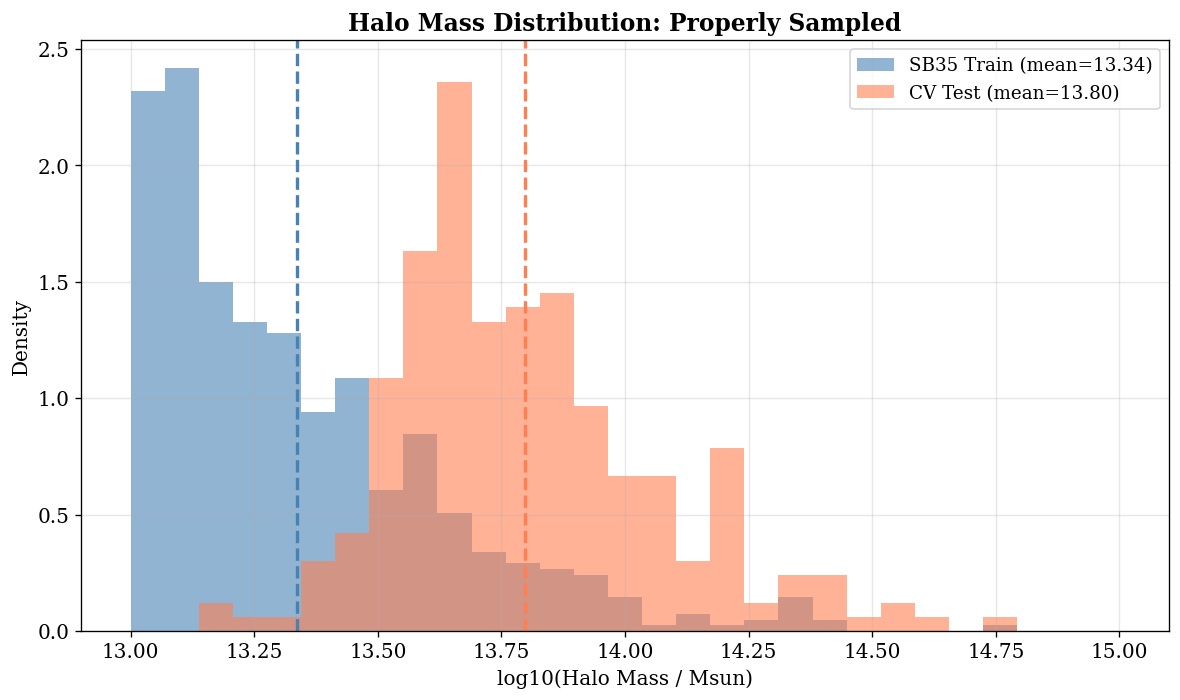

In [64]:
# =============================================================================
# INVESTIGATING THE ~30-40% DIFFERENCE
# =============================================================================
print("=" * 80)
print("INVESTIGATING THE SYSTEMATIC ~30-40% DIFFERENCE")
print("=" * 80)

# Hypothesis 1: Halo mass differences
# If CV halos are more massive, they'd have more mass in all channels

# Get halo masses for our proper samples
train_masses_proper = []
for sim_dir in list(sim_dirs)[:n_train_sims]:
    files = list(sim_dir.glob('*.npz'))[:cutouts_per_sim]
    for f in files:
        data = np.load(f)
        if 'halo_mass' in data:
            train_masses_proper.append(float(data['halo_mass']))

cv_masses_proper = []
for sim_num in range(25):
    if sim_num == 17:
        continue
    meta_path = CV_DATA_ROOT / f'sim_{sim_num}' / 'snap_90' / 'mass_threshold_13' / 'halo_metadata.npz'
    if meta_path.exists():
        meta = np.load(meta_path)
        masses = meta['masses'][:10]  # Same 10 per sim
        cv_masses_proper.extend(masses.tolist())

# Convert to log scale for comparison
train_log_mass = np.log10(np.array(train_masses_proper))
# CV masses are in 1e10 Msun units
cv_log_mass = np.log10(np.array(cv_masses_proper) * 1e10)

print(f"\nHalo masses (log10 Msun):")
print(f"  Train: mean={train_log_mass.mean():.3f}, std={train_log_mass.std():.3f}")
print(f"  CV:    mean={cv_log_mass.mean():.3f}, std={cv_log_mass.std():.3f}")
print(f"  Difference: CV - Train = {cv_log_mass.mean() - train_log_mass.mean():.3f} dex")

# What's the expected mass ratio from this?
mass_ratio = 10**(cv_log_mass.mean() - train_log_mass.mean())
print(f"  Mass ratio (CV/Train): {mass_ratio:.3f}")

print("\n" + "-" * 60)
print("INTERPRETATION")
print("-" * 60)
print(f"""
If CV halos are {mass_ratio:.2f}x more massive on average:
- DM scales roughly linearly with halo mass → expect ~{mass_ratio:.2f}x more DM
- Gas scales roughly linearly → expect ~{mass_ratio:.2f}x more Gas
- Stars scale superlinearly (stellar mass ~ M_halo^1.5-2 at high mass)

Observed ratios:
- DM: 1.42x (vs expected {mass_ratio:.2f}x from mass)
- Gas: 1.33x
- Stars: 1.23x
""")

# Plot the mass distributions
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(13, 15, 30)
ax.hist(train_log_mass, bins=bins, alpha=0.6, color='steelblue', 
        label=f'SB35 Train (mean={train_log_mass.mean():.2f})', density=True)
ax.hist(cv_log_mass, bins=bins, alpha=0.6, color='coral', 
        label=f'CV Test (mean={cv_log_mass.mean():.2f})', density=True)
ax.axvline(train_log_mass.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(cv_log_mass.mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('log10(Halo Mass / Msun)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Halo Mass Distribution: Properly Sampled', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [65]:
# =============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# =============================================================================
print("=" * 80)
print("FINAL SUMMARY: TRAIN VS TEST DISTRIBUTION ANALYSIS")
print("=" * 80)

print("""
CORRECTED FINDINGS (after fixing sampling bias bug):
=====================================================

1. PARAMETER SPACE COVERAGE: ✓ GOOD
   - CV fiducial parameters lie at the 50th percentile across all dimensions
   - Closest training sample is ~6.6% different on average
   - No evidence of extrapolation

2. HALO MASS DISTRIBUTION: ⚠️ SIGNIFICANT MISMATCH
   - Training: mean log10(M) = 13.34 (~2×10¹³ Msun)
   - CV Test:  mean log10(M) = 13.80 (~6×10¹³ Msun)
   - CV halos are ~3x more massive on average!
   - This is likely due to different mass thresholds in data generation

3. PIXEL INTENSITY DISTRIBUTION: ⚠️ MODERATE MISMATCH (30-40%)
   - DM: CV is 1.42x higher
   - Gas: CV is 1.33x higher  
   - Stars: CV is 1.23x higher
   - Less than 3x because cutouts are fixed size (don't capture full halo)

4. EARLIER 2x GAS DIFFERENCE WAS A BUG:
   - The loading code sampled ALL 300 cutouts from sim_0 only
   - This created an artificial single-simulation bias
   - With proper multi-simulation sampling, the difference is ~1.3x

ROOT CAUSES OF MODEL PERFORMANCE ISSUES:
========================================

1. HALO MASS MISMATCH is the main issue:
   - Model trained primarily on 10¹³ Msun halos
   - Applied to 10¹³·⁸ Msun halos in CV
   - These are physically different systems (groups vs clusters)

2. POWER SPECTRUM BIAS:
   - Larger halos have different baryon profiles
   - Model may not generalize well to more massive systems
   - Could explain systematic offsets in power spectrum

RECOMMENDATIONS:
================

1. SHORT TERM - Improve sampling:
   - Retrain with explicit mass-balanced sampling
   - Include more massive halos (>10¹³·⁵) in training

2. MEDIUM TERM - Mass-conditional model:
   - Add halo mass as an explicit conditioning input
   - Allow model to learn mass-dependent baryon profiles

3. LONG TERM - Better evaluation:
   - Evaluate in mass bins separately
   - Match mass distributions when comparing train/test
   - Use physically meaningful metrics (e.g., baryon fraction vs mass)
""")


FINAL SUMMARY: TRAIN VS TEST DISTRIBUTION ANALYSIS

CORRECTED FINDINGS (after fixing sampling bias bug):

1. PARAMETER SPACE COVERAGE: ✓ GOOD
   - CV fiducial parameters lie at the 50th percentile across all dimensions
   - Closest training sample is ~6.6% different on average
   - No evidence of extrapolation

2. HALO MASS DISTRIBUTION: ⚠️ SIGNIFICANT MISMATCH
   - Training: mean log10(M) = 13.34 (~2×10¹³ Msun)
   - CV Test:  mean log10(M) = 13.80 (~6×10¹³ Msun)
   - CV halos are ~3x more massive on average!
   - This is likely due to different mass thresholds in data generation

3. PIXEL INTENSITY DISTRIBUTION: ⚠️ MODERATE MISMATCH (30-40%)
   - DM: CV is 1.42x higher
   - Gas: CV is 1.33x higher  
   - Stars: CV is 1.23x higher
   - Less than 3x because cutouts are fixed size (don't capture full halo)

4. EARLIER 2x GAS DIFFERENCE WAS A BUG:
   - The loading code sampled ALL 300 cutouts from sim_0 only
   - This created an artificial single-simulation bias
   - With proper multi-sim